# The Road to Agency: How Large Language Models Work

[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/addarm/how-llms-work)


![Banner](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/llms_how_they_work_banner.png)


## Introduction

Large language models have become an integral part of our professional lives, as copilots, search assistants, coding agents, and conversational interfaces. Such ubiquitous tools are sadly not well understood, and their deep history and fundamentals not well studied. This gap is what this article aims to clean. We will dip our toes into the machinery by loading a real model ([SmolLM2-135M](https://huggingface.co/HuggingFaceTB/SmolLM2-135M)), inspecting its internals, and following the path from raw text to token IDs, from token IDs to hidden states, from hidden states to logits, and from logits back to generated text. Along the way we will interpret what each component does, why it exists, what trade-off it resolves, and what breaks when it fails.

"How Large Language Models Work" is **Part 1 of 4** of a series of articles with the them "The Road to Agency", followed by "Prompt Engineering in Depth", "The Science of Agents", and "Retrieval-Augmented Generation".


# Notebook Setup

The notebook for the article requires **PyTorch** and **Hugging Face Transformers** in addition to the standard numerical stack. The first run downloads SmolLM2-135M model weights (~540 MB total for both variants). No API keys or GPU are required — all inference runs on CPU.

In [2]:
!pip install torch transformers numpy pandas matplotlib seaborn scikit-learn --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import json, sys, math, warnings, platform
from collections import Counter
from dataclasses import dataclass, field
from typing import Optional, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers as _tf
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}  |  Transformers {_tf.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


PyTorch 2.11.0+cpu  |  Transformers 5.6.2
Device: cpu


# The LLM Architecture


Vaswani et al. (2017) introduced the transformer in *Attention Is All You Need*. The original architecture has two halves:

- **Encoder**: reads the full input sequence in parallel, producing a contextualised representation for every token. Each encoder layer applies **bidirectional self-attention** (every token attends to every other token) followed by a feed-forward network.
- **Decoder**: generates the output sequence one token at a time. Each decoder layer applies **causal (masked) self-attention** (a token can only attend to earlier positions), then **cross-attention** over the encoder's output, then a feed-forward network.

The key innovation was replacing recurrence entirely with attention, enabling massive parallelism during training.

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

| Family | Architecture | Attention mask | Training objective | Representative models | Primary use-cases |
|--------|-------------|---------------|-------------------|----------------------|------------------|
| **Encoder-only** | Encoder stack only | Bidirectional (full) | Masked Language Modeling (MLM) | BERT, RoBERTa, DeBERTa | Classification, NER, retrieval |
| **Encoder-decoder** | Full original transformer | Bidirectional encoder, causal decoder | Span corruption / seq2seq | T5, BART, Flan-T5 | Translation, summarization |
| **Decoder-only** | Decoder stack only (no cross-attention) | Causal (triangular mask) | Next-token prediction | GPT-2/3/4, Llama, SmolLM2 | Text generation, chat, code |


Radford et al. (2018) dropped the encoder entirely, created what became the poster child of AI throgh ChatGPT (and Llama, Mistral, SmolLM2). GPT uses only the decoder stack trained on a single objective to predict the next token. This setup was simple,  one stack, one objective, one data pipeline and generalizes well, as any NLP task can be reformulated as text generation. What also surprised teh world is its **Emergent capabilities**, at scale, decoder-only models exhibit in-context learning, chain-of-thought reasoning, and instruction-following simulating intelligence like we never experienced.


## Working with a Real LLM

We will use **SmolLM2-135M** (Allal et al., 2025) throughout this article. It is a 135 M-parameter causal language model from the Llama family with RoPE positional encoding, Grouped-Query Attention (GQA), SiLU activations, Pre-LN transformer blocks - the same design used by Llama 3, Mistral, and Qwen2.

We load both variants: **Base** (`SmolLM2-135M`) for a pretrained next-token predictor, and **Instruct** (`SmolLM2-135M-Instruct`) for the architecture with SFT + DPO aligned to follow instructions. Later sections will compare the two.


In [4]:
# Load SmolLM2-135M base and instruct variants
BASE_ID = "HuggingFaceTB/SmolLM2-135M"
INST_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(BASE_ID)
model_base = AutoModelForCausalLM.from_pretrained(
    BASE_ID,
    dtype=torch.float32,
    attn_implementation="eager",
)
model_inst = AutoModelForCausalLM.from_pretrained(
    INST_ID,
    dtype=torch.float32,
    attn_implementation="eager",
)
model_base.eval()
model_inst.eval()
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")
print(f"Base model parameters: {sum(p.numel() for p in model_base.parameters()):,}")
print(f"Instruct model parameters: {sum(p.numel() for p in model_inst.parameters()):,}")


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Tokenizer vocab size: 49,152
Base model parameters: 134,515,008
Instruct model parameters: 134,515,008


In [5]:
# Inspect SmolLM2-135M architecture from its config
cfg = model_base.config
rows = [
    ("Architecture class", cfg.architectures[0] if cfg.architectures else "N/A"),
    ("Hidden size (d_model)", cfg.hidden_size),
    ("Num layers", cfg.num_hidden_layers),
    ("Num attention heads", cfg.num_attention_heads),
    ("Num KV heads (GQA)", cfg.num_key_value_heads),
    (
        "GQA ratio",
        f"{cfg.num_attention_heads}:{cfg.num_key_value_heads}  ({cfg.num_attention_heads // cfg.num_key_value_heads} queries per KV head)",
    ),
    ("Intermediate (FFN) size", cfg.intermediate_size),
    ("Activation function", cfg.hidden_act),
    ("Max position embeddings", cfg.max_position_embeddings),
    ("RoPE theta", getattr(cfg, "rope_theta", "N/A")),
    ("Vocab size", cfg.vocab_size),
    ("Tie word embeddings", cfg.tie_word_embeddings),
]
df_cfg = pd.DataFrame(rows, columns=["Parameter", "Value"])
print(df_cfg.to_string(index=False))


              Parameter                        Value
     Architecture class             LlamaForCausalLM
  Hidden size (d_model)                          576
             Num layers                           30
    Num attention heads                            9
     Num KV heads (GQA)                            3
              GQA ratio 9:3  (3 queries per KV head)
Intermediate (FFN) size                         1536
    Activation function                         silu
Max position embeddings                         8192
             RoPE theta                          N/A
             Vocab size                        49152
    Tie word embeddings                         True


## Next-Token Prediction

Language modeling, or "understanding language", is just a problem of predicting the next token from the tokens already seen. Given a token sequence: $x_1, x_2, \dots, x_T$, an autoregressive language model writes the probability of the full sequence as a chain of predictions:

$$
P(x_1, x_2, \dots, x_T)
=
\prod_{t=1}^{T}
P(x_t \mid x_1, \dots, x_{t-1})
$$

This means the model does not predict the whole sequence at once. It learns one conditional prediction at a time. The model is trained by minimizing **cross-entropy loss**:

$$
\mathcal{L}
=
-\sum_{t=1}^{T}
\log p_\theta(x_t \mid x_{<t})
$$

where $\theta$ are the model parameters, and $x_{<t}$ means all tokens before position $t$. This loss function simply measures how much probability did the model assign to the true next token? If the correct token receives high probability, the loss is small. If the correct token receives low probability, the loss is large. And as you can see, it is self-supervised - the text is its own label.

In fact, during training, the input and target are the same sequence shifted by one position.

$$
(x_1, x_2, \dots, x_{T-1})
\;\mapsto\;
(x_2, x_3, \dots, x_T)
$$

So the model sees $x_1$ and learns to predict $x_2$. Then it sees $x_1, x_2$ and learns to predict $x_3$. This continues across the sequence.

At training time, the model receives the **ground-truth previous tokens** as context. This is called **teacher forcing**. The model is not trained by feeding back its own mistakes during the sequence; it is trained against the real text prefix.

At inference time, no ground-truth next token is available. The model must generate a token, append it to the context, and then use that enlarged context to generate the next token. Generation is therefore an autoregressive loop as visualized in this diagram:


```mermaid
flowchart LR
    A["Context tokens<br/>x₁, x₂, ..., xₜ"]
    B["Transformer<br/>causal attention"]
    C["Contextual hidden vector<br/>hₜ ∈ ℝᵈ"]
    D["LM head<br/>zₜ = W_LM hₜ"]
    E["Logits<br/>zₜ ∈ ℝ^|V|"]
    F["Softmax"]
    G["Vocabulary probabilities<br/>pθ(xₜ₊₁ | x≤t)"]
    H["Decode<br/>select next token"]
    I["xₜ₊₁"]

    A --> B --> C --> D --> E --> F --> G --> H --> I
    I -. "append and repeat" .-> A
```


At each position $t$, the transformer produces a contextual hidden vector:

$$
h_t \in \mathbb{R}^{d}
$$

Here, $d$ is the hidden dimension. The vector $h_t$ is the model's contextual representation at position $t$: it contains information from the current token and from previous tokens through causal attention.

$$
h_t \in \mathbb{R}^{d}
\quad\longmapsto\quad
z_t = W_{\mathrm{LM}}h_t \in \mathbb{R}^{|V|},
\qquad
W_{\mathrm{LM}} \in \mathbb{R}^{|V| \times d}
$$

Note that the hidden vector $h_t$ has length $d$, while the vocabulary has $|V|$ possible tokens. So the LM head maps from hidden space to vocabulary space:

$$
\mathbb{R}^{d} \rightarrow \mathbb{R}^{|V|}
$$

After this projection, $z_t$ contains one score for every possible token in the vocabulary. These scores are called **logits**. They are not probabilities,  but unnormalized scores. To convert logits into probabilities, the model applies softmax:

$$
p_\theta(x_{t+1} \mid x_{\leq t})
=
\mathrm{softmax}(z_t)
$$

Now the output is a probability distribution over the full vocabulary:

$$
\sum_{i=1}^{|V|} p_i = 1
$$

A decoding rule then selects the next token from this distribution. Greedy decoding chooses the highest-probability token. Sampling draws from the distribution. Methods such as top-$k$, top-$p$, and temperature modify how conservative or diverse that selection is.

In many modern models, the LM head matrix $W_{\mathrm{LM}}$ is tied to the input embedding matrix $E$. This means the model reuses the same token representation space at both ends of the network: token IDs are mapped into vectors at the input, and hidden vectors are mapped back toward token scores at the output. Since the model assigns probability to every token in the vocabulary at every step, it does not check if the continuation is true, only  if it is likely - this is what causes **hallucination**.

This next-token prediction is the base mechanism behind everything else. More sophisticated LLM capabilities (in the next article) and agent behavior are shaped by post-training, but the runtime loop remains the same: context becomes a hidden state, the hidden state becomes logits, logits become probabilities, and a decoding rule selects the next token. The model repeats that loop one token at a time.

```mermaid
flowchart LR
    A["Context up to position t<br/>x₁, x₂, …, x_t"] --> B["Transformer with causal attention"]
    B --> C["Contextual hidden state<br/>h_t ∈ ℝ^d"]

    C --> D["LM head (linear projection)<br/>z_t = W_LM h_t<br/>W_LM ∈ ℝ^|V|×d"]
    D --> E["Logits over vocabulary<br/>z_t ∈ ℝ^|V|"]

    E --> F["Softmax"]
    F --> G["Next-token distribution<br/>pθ(x_{t+1} | x_{≤t})"]

    G --> H["Decoding rule<br/>greedy / sampling / top-k / top-p / temperature"]
    H --> I["Selected next token<br/>x_{t+1}"]

    I --> J["Append token to context"]
    J --> K["New context<br/>x₁, x₂, …, x_t, x_{t+1}"]
    K --> B

    L["Vocabulary space<br/>ℝ^|V|"] -.-> E
    M["Hidden space<br/>ℝ^d"] -.-> C
    N["Often W_LM is tied to the input embedding matrix"] -.-> D
    O["The model predicts likely next tokens,<br/>not guaranteed true ones"] -.-> G
```

The code below demostrates the concepts we just learned:

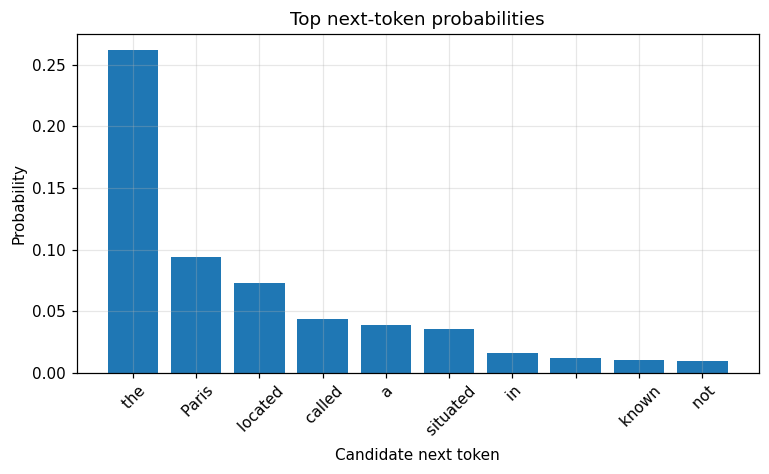

Prompt: The capital of France is
Greedy next token: ' the'
Sampled next token: ' Paris'
Top-k sampled next token: ' located'


In [6]:
import torch
import matplotlib.pyplot as plt

prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    logits = model_base(**inputs).logits[:, -1, :]
    probs = torch.softmax(logits, dim=-1)

top = torch.topk(probs, k=10)
tokens = [tokenizer.decode([i]) for i in top.indices[0].tolist()]
values = top.values[0].tolist()

plt.figure(figsize=(8, 4))
plt.bar(tokens, values)
plt.title("Top next-token probabilities")
plt.xlabel("Candidate next token")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.show()

greedy_id = torch.argmax(probs, dim=-1).item()
sampled_id = torch.multinomial(probs[0], num_samples=1).item()

top_k = 10
top_probs, top_ids = torch.topk(probs[0], k=top_k)
top_probs = top_probs / top_probs.sum()
topk_sampled_id = top_ids[torch.multinomial(top_probs, num_samples=1)].item()

print("Prompt:", prompt)
print("Greedy next token:", repr(tokenizer.decode([greedy_id])))
print("Sampled next token:", repr(tokenizer.decode([sampled_id])))
print("Top-k sampled next token:", repr(tokenizer.decode([topk_sampled_id])))


In [7]:
def decode_steps(model, tokenizer, prompt, steps=20, temperature=1.0, top_k=None, greedy=False, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]

    for _ in range(steps):
        with torch.no_grad():
            logits = model(input_ids).logits[:, -1, :]

        if greedy:
            next_id = torch.argmax(logits, dim=-1).view(1, 1)
        else:
            if temperature <= 0:
                raise ValueError("temperature must be > 0 when greedy=False")

            logits = logits / temperature

            if top_k is not None:
                values, indices = torch.topk(logits, k=top_k)
                filtered = torch.full_like(logits, float("-inf"))
                filtered.scatter_(1, indices, values)
                logits = filtered

            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs[0], num_samples=1).view(1, 1)

        input_ids = torch.cat([input_ids, next_id], dim=1)

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


prompt_true = "The capital of France is"
prompt_false = "The capital of Mars is"

print("Greedy deterministic:")
print(
    decode_steps(
        model_base,
        tokenizer,
        prompt_true,
        steps=20,
        greedy=True,
    )
)

print("\nTop-k sampled reproducible with seed:")
print(
    decode_steps(
        model_base,
        tokenizer,
        prompt_true,
        steps=20,
        temperature=0.8,
        top_k=10,
        seed=42,
    )
)

print("\nTop-k sampled different seed:")
print(
    decode_steps(
        model_base,
        tokenizer,
        prompt_true,
        steps=20,
        temperature=0.8,
        top_k=10,
        seed=7,
    )
)

print("\nFalse-premise prompt:")
print(
    decode_steps(
        model_base,
        tokenizer,
        prompt_false,
        steps=20,
        temperature=0.8,
        top_k=10,
        seed=42,
    )
)


Greedy deterministic:
The capital of France is the capital of the country.

The capital of France is the capital of the country.


Top-k sampled reproducible with seed:
The capital of France is Paris.

The word ‘Paris’ is French and means ‘city’. The word ‘Paris

Top-k sampled different seed:
The capital of France is not Paris but Paris is called the capital of France. It is in a region called the Champagne

False-premise prompt:
The capital of Mars is a city of many cities, with a long history of commerce, and an impressive and extensive network of


The plot and outputs show the same mechanism at two scales: **one-token prediction** and **repeated decoding**. First, the model reads the prompt: $\text{The capital of France is}$. It then produces a probability distribution over the full vocabulary. The chart only shows the top candidate tokens. In this run, the highest-probability next token is: $\text{`` the''}$, not: $\text{`` Paris''}$.

This matters because the model is not answering the question in one step. It is predicting the next token. The token `" the"` is likely because the sentence can naturally continue as: $\text{The capital of France is the capital of the country.}$, or, $\text{The capital of France is the city of Paris.}$. So `"Paris"` may still appear later, but it does not need to be the immediate next token.

The decoding output shows two important ideas. First, **greedy decoding is deterministic**. It always chooses the highest-probability token at each step. In this example, that produces a repetitive continuation: $\text{The capital of France is the capital of the country.}$
The model then starts repeating a similar pattern again. This is a common failure mode of greedy decoding: it is stable, but not always good. Second, **sampling is probabilistic**. With top-$k$ sampling, the model samples from only the top $k$ candidate tokens. If we use the same random seed, we get the same sampled output: $\text{The capital of France is Paris.}$.

If we change the seed, the same model and same prompt can produce a different continuation: $\text{The capital of France is not Paris but Paris is called the capital of France...}$. These outputs come from the same model and the same next-token mechanism. The difference is the decoding rule and, for sampling, the random draw.

| Decoding method | What it does | Behavior |
|---|---|---|
| Greedy decoding | Always chooses the highest-probability token | Deterministic, but can be repetitive |
| Top-$k$ sampling with fixed seed | Samples from the top $k$ tokens with controlled randomness | Reproducible |
| Top-$k$ sampling with different seed | Samples from the same distribution using a different random draw | Different output |

As shown in the diagram previously, generation is iterative. The selected token is appended to the context, and the model runs the same prediction step again for the next position. At every step, the model predicts only the next token. It does not generate the whole answer at once.

The false-premise example shows the hallucination risk: $\text{The capital of Mars is}$. Mars does not have a capital until Elon Musk colonizes it. But the model still continues fluently: $\text{The capital of Mars is a city of many cities...}$ This happens because the decoding loop asks gets the next likely token not the true one. That is the core failure behind any hallucination. 

## Tokens and Embeddings

A language model cannot work directly with raw text. Before text reaches the transformer, it must be converted into numerical form. This happens in two steps:

1. text is split into **tokens** with assigned token IDs
2. token IDs are mapped into **embedding vectors**

A token can be a word, part of a word, punctuation, whitespace, or a byte-level fragment. The exact split depends on the tokenizer. For example, the text: $\text{unbelievable}$, might be represented as smaller subword pieces rather than one full word: $\text{un} \;+\; \text{believ} \;+\; \text{able}$.  This is useful because models need a finite vocabulary, but natural language contains too many possible words, names, spellings, and combinations.

Tokenization is a compromise between three bad extremes:

| Tokenization level | Benefit | Cost |
|---|---|---|
| Character-level | Very small vocabulary | Very long sequences |
| Word-level | Shorter sequences | Huge vocabulary and many unknown words |
| Subword-level | Handles rare and new words by composition | Tokens are not always intuitive to humans |

Most modern language models use subword tokenization, often with methods such as byte-pair encoding, SentencePiece, or byte-level BPE. These methods let the model represent common words efficiently while still being able to break rare words into smaller pieces.

After tokenization, each token is converted into a token ID:

$$
x_t \in \{1, 2, \dots, |V|\}
$$

Here, $|V|$ is the vocabulary size. The token ID is not meaningful by itself. It is just an index into the model's embedding table. The embedding table is a learned matrix:

$$
E \in \mathbb{R}^{|V| \times d}
$$

Each row of this matrix stores one vector for one token. So token $x_t$ is mapped to an embedding vector:

$$
\mathbf{e}_t = E[x_t]
$$

$$
\mathbf{e}_t \in \mathbb{R}^{d}
$$

Here, $d$ is the hidden dimension of the model. The embedding vector is the model's initial numerical representation of the token before attention, feed-forward layers, and contextual mixing happen. The embedding is not yet the model's full understanding of the word. At this stage, it is still a static lookup vector. The contextual meaning is built later by the transformer, when tokens attend to other tokens in the sequence. The diagram below shows the full path from text to transformer input:



```mermaid
flowchart LR
    A["Raw text<br/>'unbelievable'"] 
    B["Tokenizer"]
    C["Tokens<br/>['un', 'believ', 'able']"]
    D["Token IDs<br/>[542, 8912, 481]"]
    E["Embedding table<br/>E ∈ R^{|V| × d}"]
    F["Embedding vectors<br/>e₁, e₂, e₃ ∈ R^d"]
    G["Transformer layers"]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
```



A common mistake is to assume the model sees text the same way humans do. It does not. It sees token IDs. This is why models can struggle with character-level tasks such as: $\text{How many letters are in ``strawberry''?}$, the model may not see each character separately. It may see one or more subword tokens instead. In fact let's try it in code:

=== Real BPE Tokenization (SmolLM2) ===

Text:   The transformer architecture revolutionized natural language processin
Tokens: ['The', 'Ġtransformer', 'Ġarchitecture', 'Ġrevolutionized', 'Ġnatural', 'Ġlanguage', 'Ġprocessing', '.']
IDs:    [504, 26832, 6277, 25774, 1782, 1789, 4604, 30]
  → 8 tokens for 72 chars (9.0 chars/tok)

Text:   SmolLM2 uses byte-level BPE with a 49,152-token vocabulary.
Tokens: ['Sm', 'ol', 'LM', '2', 'Ġuses', 'Ġbyte', '-', 'level', 'ĠB', 'PE', 'Ġwith', 'Ġa', 'Ġ', '4', '9']...
IDs:    [9207, 308, 34519, 34, 2925, 23860, 29, 4638, 389, 8198, 351, 253, 216, 36, 41]...
  → 23 tokens for 59 chars (2.6 chars/tok)

Text:   def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-
Tokens: ['def', 'Ġfib', 'onacci', '(', 'n', '):', 'Ġreturn', 'Ġn', 'Ġif', 'Ġn', 'Ġ<', 'Ġ', '2', 'Ġelse', 'Ġfib']...
IDs:    [1604, 3987, 46477, 24, 94, 727, 1003, 304, 585, 304, 2067, 216, 34, 1745, 3987]...
  → 29 tokens for 72 chars (2.5 chars/tok)

Text:   Die Transformer-A

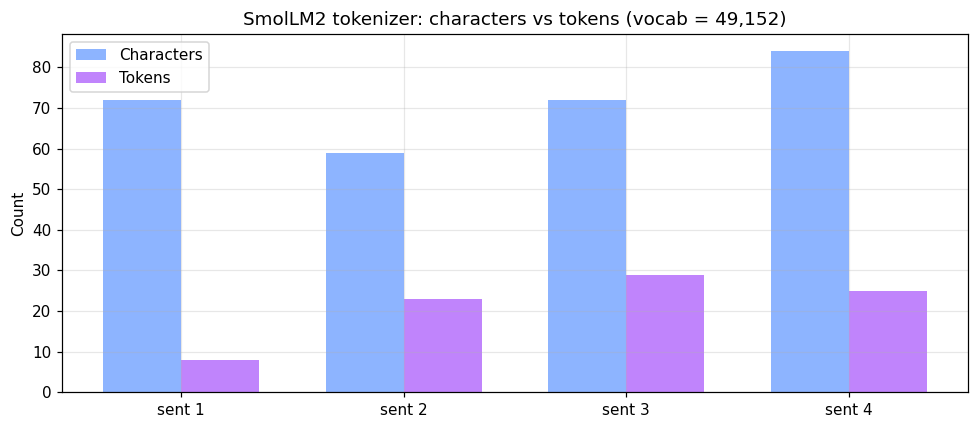

In [8]:
sentences = [
    "The transformer architecture revolutionized natural language processing.",
    "SmolLM2 uses byte-level BPE with a 49,152-token vocabulary.",
    "def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)",
    "Die Transformer-Architektur hat die Verarbeitung natürlicher Sprache revolutioniert.",
]

print("=== Real BPE Tokenization (SmolLM2) ===\n")
records = []
for s in sentences:
    ids = tokenizer.encode(s, add_special_tokens=False)
    toks = tokenizer.convert_ids_to_tokens(ids)
    records.append(
        {
            "text": s[:55] + ("..." if len(s) > 55 else ""),
            "chars": len(s),
            "tokens": len(ids),
            "ratio": f"{len(s) / len(ids):.1f} chars/tok",
        }
    )
    print(f"Text:   {s[:70]}")
    print(f"Tokens: {toks[:15]}{'...' if len(toks) > 15 else ''}")
    print(f"IDs:    {ids[:15]}{'...' if len(ids) > 15 else ''}")
    print(f"  → {len(ids)} tokens for {len(s)} chars ({len(s) / len(ids):.1f} chars/tok)\n")

df_tok = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(df_tok))
ax.bar(x, df_tok["chars"], width=0.35, label="Characters", color="#8db4ff", align="center")
ax.bar([i + 0.35 for i in x], df_tok["tokens"], width=0.35, label="Tokens", color="#c084fc", align="center")
ax.set_xticks([i + 0.175 for i in x])
ax.set_xticklabels([f"sent {i + 1}" for i in x])
ax.set_ylabel("Count")
ax.set_title(f"SmolLM2 tokenizer: characters vs tokens (vocab = {tokenizer.vocab_size:,})")
ax.legend()
plt.tight_layout()
plt.show()


This example shows that the model does not read text as characters or words. It reads **tokens**. The first sentence is ordinary English prose, so the tokenizer compresses it efficiently: 72 characters become only 8 tokens. The code example is different. Symbols, brackets, operators, and repeated function names split into many smaller pieces, so 72 characters become 29 tokens. The German sentence also uses more tokens than the simple English sentence because multilingual text may be segmented less efficiently by this tokenizer. This matters because tokens are the unit the model actually processes. They determine how much text fits into the context window, how expensive an API call is, and how much work the transformer must do.

In [9]:
word = "strawberry"

ids = tokenizer.encode(word, add_special_tokens=False)
tokens = tokenizer.convert_ids_to_tokens(ids)

print("Human view:")
print(list(word))
print("Characters:", len(word))

print("\nModel view:")
print(tokens)
print("Token IDs:", ids)
print("Tokens:", len(tokens))

Human view:
['s', 't', 'r', 'a', 'w', 'b', 'e', 'r', 'r', 'y']
Characters: 10

Model view:
['st', 'raw', 'berry']
Token IDs: [302, 1709, 9500]
Tokens: 3


In [10]:
prompt = "How many r letters are in strawberry?"

inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    out_base = model_base.generate(
        **inputs,
        max_new_tokens=30,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

print(tokenizer.decode(out_base[0], skip_special_tokens=True))

How many r letters are in strawberry?

The strawberry is a fruit that is native to the Mediterranean region. It is a berry that is about 10 cm in diameter. The


This example shows why character-level questions can be awkward for language models. A human sees the word as individual letters:

$$
\text{s, t, r, a, w, b, e, r, r, y}
$$

So the human can directly count the three `"r"` letters. The model sees something different. SmolLM2's tokenizer splits `"strawberry"` into three tokens:

$$
\text{st} \;+\; \text{raw} \;+\; \text{berry}
$$

So the model does not receive ten separate character units. It receives three token IDs: $[302,\;1709,\;9500]$

This means the question is misaligned with the model's native representation. We ask about letters, but the model operates over tokens. The generated answer also shows another issue: this is the **base model**, so it behaves like a text-completion model, not a careful instruction-following assistant. Instead of answering the counting question, it continues with plausible text about strawberries: $\text{The strawberry is a fruit...}$. Since we mentioned that we will try the two variants, here is the code for the instruction following model:

In [11]:
tokenizer_inst = AutoTokenizer.from_pretrained(INST_ID)

word = "strawberry"
prompt = f"How many r letters are in {word}? Answer with only the number."

inputs = tokenizer_inst(prompt, return_tensors="pt")

with torch.no_grad():
    output = model_inst.generate(
        **inputs,
        max_new_tokens=6,
        do_sample=False,
        pad_token_id=tokenizer_inst.eos_token_id,
    )

completion = tokenizer_inst.decode(output[0], skip_special_tokens=True)
answer = completion[len(prompt) :].strip()

print("Prompt:")
print(prompt)

print("\nCorrect answer:")
print(word.count("r"))

print("\nInstruction-tuned model answer:")
print(answer)


Prompt:
How many r letters are in strawberry? Answer with only the number.

Correct answer:
3

Instruction-tuned model answer:
Answer: 1


Still wrong but we know why.

## Similarity in Embeddings

Embedding vectors are not just arbitrary numbers. During training, the model learns to place tokens in a high-dimensional space so that tokens used in similar contexts often end up with similar vectors. This means we can compare tokens geometrically.

A common way to measure this is **cosine similarity**. For two embedding vectors $\mathbf{u}$ and $\mathbf{v}$,

$$
\cos(\theta) = \frac{\mathbf{u}^\top \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}
$$

If the cosine similarity is close to $1$, the vectors point in a similar direction. If it is near $0$, they are mostly unrelated. If it is negative, they point in opposite directions. Think of the semantic structure inside the embedding table for tokens like `"dog"` and `"cat"` or `"car"` and `"truck"`, which often end up more similar than unrelated pairs.

let's demostrate this with code:

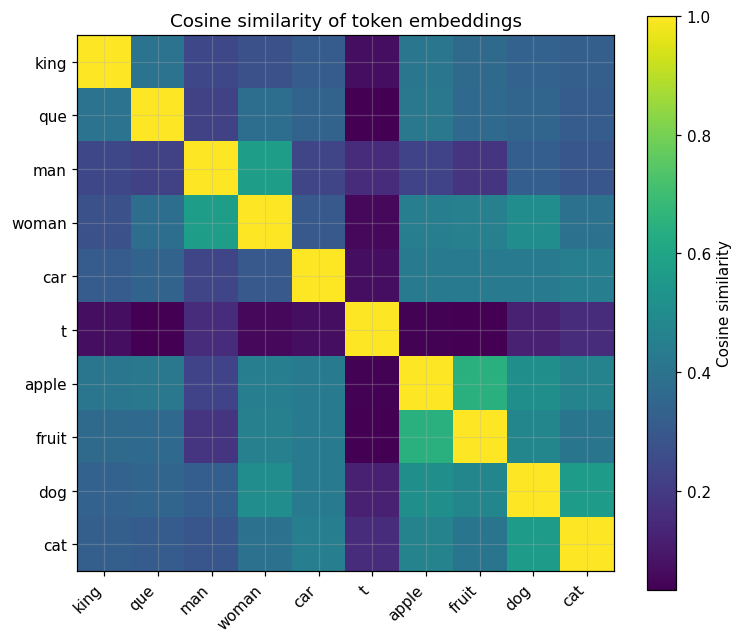

In [12]:
probe_words = ["king", "queen", "man", "woman", "car", "truck", "apple", "fruit", "dog", "cat"]

emb = model_base.get_input_embeddings().weight.detach().cpu().numpy()

vecs = []
labels = []

for word in probe_words:
    ids = tokenizer.encode(word, add_special_tokens=False)
    token = tokenizer.convert_ids_to_tokens(ids)[0]
    vecs.append(emb[ids[0]])
    labels.append(token)

vecs = np.stack(vecs)
vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)
sim = vecs @ vecs.T


plt.figure(figsize=(7, 6))
plt.imshow(sim)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
plt.colorbar(label="Cosine similarity")
plt.title("Cosine similarity of token embeddings")
plt.tight_layout()
plt.show()


This heatmap shows cosine similarity between selected **input token embeddings** from SmolLM2. The diagonal is always $1.00$ because each token is perfectly similar to itself. Some relationships are intuitive: `"apple"` and `"fruit"` are close, `"dog"` and `"cat"` are close, and `"man"` and `"woman"` are close. This suggests the embedding table has learned broad semantic structure from training data.

There is also an important tokenizer detail. `"truck"` appears as `"t"` because the code took only the first token when a word was split into subwords. That means the `"truck"` row is not really measuring the word `"truck"`; it is measuring the embedding for the token `"t"`. Embedding depend on the tokenization function.

These vectors are still **static embeddings**. They show the model's learned starting representation for each token, not the final contextual meaning inside a sentence.

## Positional Encoding

A transformer sees a sequence as a list of vectors:

$$
\mathbf{e}_1, \mathbf{e}_2, \dots, \mathbf{e}_T
$$

But self-attention, by itself, does not know where each vector came from. It compares tokens by content, not by position. Without positional information, these two sentences contain the same tokens:

$$
\text{the cat sat on the mat}
$$

$$
\text{mat the on sat cat the}
$$

Clearly do not mean the same thing! So the model needs a way to represent **order**.




### Sinusoidal positional encoding

The original Transformer added a positional vector to each token embedding. So the model did not only receive the token vector:

$$
\mathbf{e}_t
$$

It received:

$$
\mathbf{x}_t = \mathbf{e}_t + \mathbf{p}_t
$$

where $\mathbf{p}_t$ is the positional encoding for position $t$. Vaswani et al. used sine and cosine waves at different frequencies:

$$
PE_{(pos, 2i)} =
\sin\!\left(\frac{pos}{10000^{2i/d}}\right)
$$

$$
PE_{(pos, 2i+1)} =
\cos\!\left(\frac{pos}{10000^{2i/d}}\right)
$$

The intuition is simple: each position gets a unique wave pattern. Nearby positions have similar patterns, and distant positions have increasingly different patterns. So the model receives both: $\text{what token is this?}$ and $\text{where is this token?}$.

For example, the word `"cat"` in position 2 and the word `"cat"` in position 20 start with the same token embedding, but after adding positional encoding they become different input vectors:

$$
\mathbf{x}_2 = \mathbf{e}_{cat} + \mathbf{p}_2
$$

$$
\mathbf{x}_{20} = \mathbf{e}_{cat} + \mathbf{p}_{20}
$$

This creates a different vector.

The code below helps us visualize this technique:



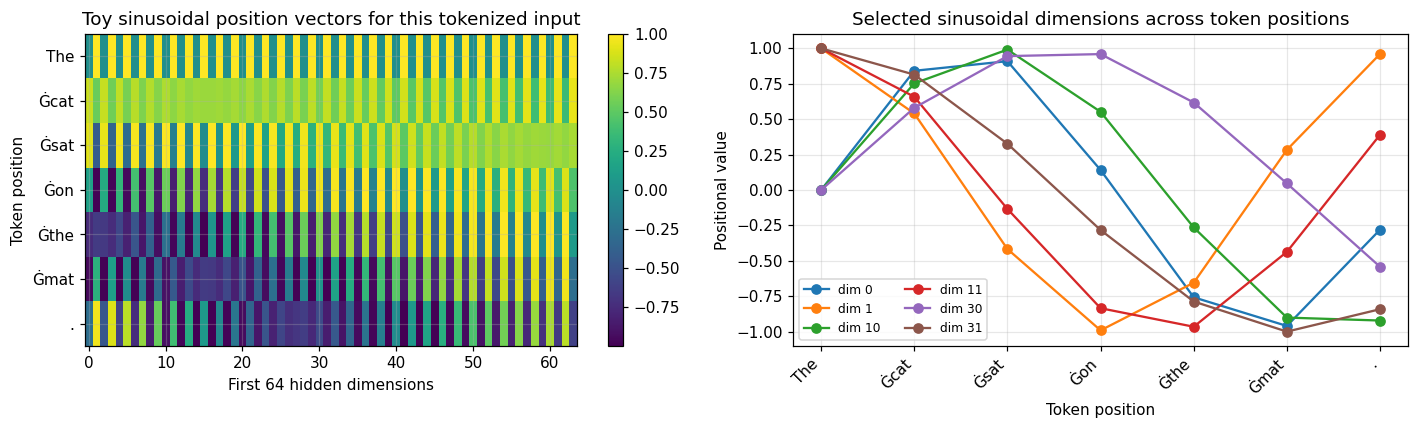

Text: The cat sat on the mat.
Token IDs: [504, 2644, 2643, 335, 260, 1171, 30]
Tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', '.']
Model hidden size: 576
Sinusoidal PE shape: (7, 576)


In [13]:
text = "The cat sat on the mat."
ids = tokenizer.encode(text, add_special_tokens=False)
tokens = tokenizer.convert_ids_to_tokens(ids)

seq_len = len(ids)
d_model = model_base.config.hidden_size

position = np.arange(seq_len)[:, None]
dim_pair = np.arange(0, d_model, 2)[None, :]
div_term = 10000.0 ** (dim_pair / d_model)

pe = np.zeros((seq_len, d_model))
pe[:, 0::2] = np.sin(position / div_term)
pe[:, 1::2] = np.cos(position / div_term)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(pe[:, :64], aspect="auto")
axes[0].set_title("Toy sinusoidal position vectors for this tokenized input")
axes[0].set_xlabel("First 64 hidden dimensions")
axes[0].set_ylabel("Token position")
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(tokens)
fig.colorbar(im, ax=axes[0])

for dim_idx in [0, 1, 10, 11, 30, 31]:
    axes[1].plot(range(seq_len), pe[:, dim_idx], marker="o", label=f"dim {dim_idx}")

axes[1].set_title("Selected sinusoidal dimensions across token positions")
axes[1].set_xlabel("Token position")
axes[1].set_ylabel("Positional value")
axes[1].set_xticks(range(seq_len))
axes[1].set_xticklabels(tokens, rotation=45, ha="right")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

print("Text:", text)
print("Token IDs:", ids)
print("Tokens:", tokens)
print("Model hidden size:", d_model)
print("Sinusoidal PE shape:", pe.shape)

This code connects positional encoding to the actual tokenized input. The original text is tokenized, into seven tokens: $[\text{The},\; \text{Ġcat},\; \text{Ġsat},\; \text{Ġon},\; \text{Ġthe},\; \text{Ġmat},\; \text{.}]$

The `Ġ` marker means the token begins with a space. So `"cat"` after a space is represented differently from `"cat"` without a space. The model hidden size is: $d = 576$, so in this toy sinusoidal example, each token position receives a positional vector:

$$
\mathbf{p}_t \in \mathbb{R}^{576}
$$

The heatmap shows the first 64 dimensions of these positional vectors. Each row is one token position. Each column is one hidden dimension. The pattern changes across rows, which means each token position receives a different numerical signature.

The line plot shows a few selected dimensions across the token positions. Some dimensions change quickly, while others change more slowly, different frequencies give the model both short-range and longer-range position signals.

Note that this is not SmolLM2's actual positional mechanism. SmolLM2 uses RoPE, we just needed a visualization of how the model knows where a token is in the sequence.


### Rotary Position Embeddings

Modern decoder models, including our toy model, use **Rotary Position Embeddings** (RoPE).

RoPE works differently. Instead of adding a positional vector to the token embedding, it rotates the **query** and **key** vectors before attention is computed. Recall that attention compares a query and a key using a dot product:

$$
q^\top k
$$

With RoPE, the query at position $m$ and the key at position $n$ are rotated by position-dependent rotation matrices:

$$
\mathbf{R}(m)q
$$

$$
\mathbf{R}(n)k
$$

Then attention compares the rotated versions:

$$
\langle \mathbf{R}(m)q,\; \mathbf{R}(n)k \rangle
$$

$$
\langle \mathbf{R}(m)q,\; \mathbf{R}(n)k \rangle
=
q^\top \mathbf{R}(n-m)k
$$

This means the attention score depends on the relative distance between the two positions: $n - m$, not only on their absolute positions. With RoPE, attention becomes aware of relative position.


Suppose token $i$ attends to token $j$. The model should know whether $j$ is:

$$
\text{one token behind}
$$

$$
\text{fifty tokens behind}
$$

These two cases should not look the same.

RoPE encodes this distance directly into the query-key comparison. The content vectors still matter, but the attention score also carries information about how far apart the tokens are.

So attention is not just asking: if this token matches the other, but also at this relative distance. Position encoding is one reason context length is not just a memory problem. A model may technically accept a long sequence, but it also needs its positional mechanism to behave sensibly at those distances.

If a model was trained mostly up to a certain context length, pushing it far beyond that range can degrade quality. The model may still run, but attention patterns can become less reliable.

Methods such as **NTK-aware scaling**, **RoPE scaling**, and **YaRN** try to stretch or interpolate the positional system so the model can handle longer contexts. These methods help, but they do not make long-context reasoning perfect. Long context models will lose track of information, or over focus recent tokens - missing the detail in the middle.

The following code illustrates RoPE:

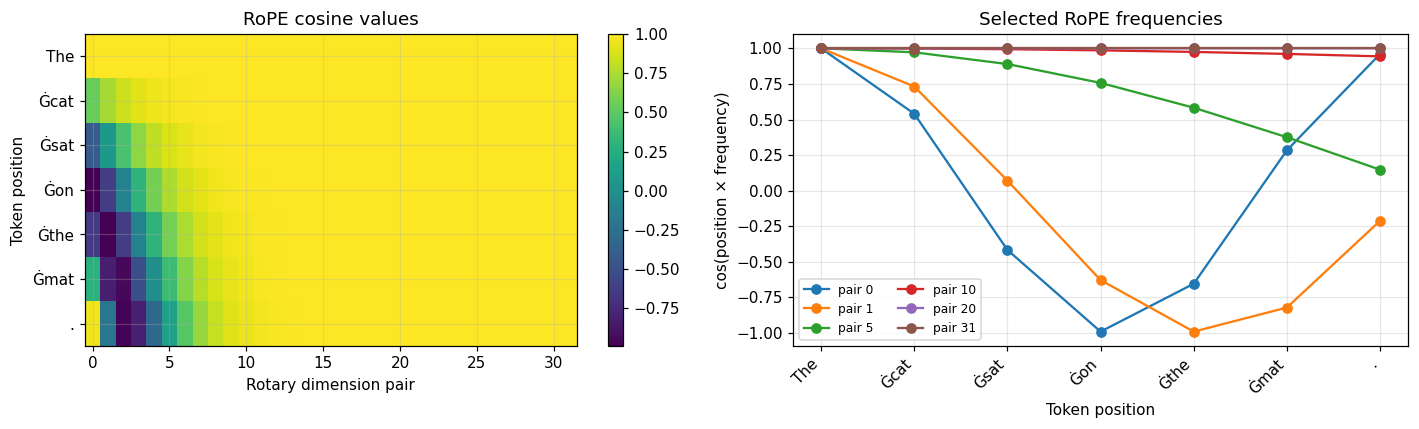

Tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', '.']
Head dim: 64
RoPE theta: 10000.0
Query token: Ġcat
Key token: Ġmat
Relative offset: 4
Absolute-position score: 5.025173114050545
Relative-offset score: 5.025173114050546
Difference: 8.881784197001252e-16


In [14]:
import numpy as np
import matplotlib.pyplot as plt

text = "The cat sat on the mat."
ids = tokenizer.encode(text, add_special_tokens=False)
tokens = tokenizer.convert_ids_to_tokens(ids)

seq_len = len(ids)
head_dim = model_base.config.hidden_size // model_base.config.num_attention_heads
theta = getattr(model_base.config, "rope_theta", 10000.0)

pos = np.arange(seq_len)[:, None]
pairs = np.arange(0, head_dim, 2)[None, :]
freqs = 1.0 / (theta ** (pairs / head_dim))
angles = pos * freqs
cos_vals = np.cos(angles)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(cos_vals, aspect="auto")
axes[0].set_title("RoPE cosine values")
axes[0].set_xlabel("Rotary dimension pair")
axes[0].set_ylabel("Token position")
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(tokens)
fig.colorbar(im, ax=axes[0])

for pair in [0, 1, 5, 10, 20, 31]:
    if pair < cos_vals.shape[1]:
        axes[1].plot(range(seq_len), cos_vals[:, pair], marker="o", label=f"pair {pair}")

axes[1].set_title("Selected RoPE frequencies")
axes[1].set_xlabel("Token position")
axes[1].set_ylabel("cos(position × frequency)")
axes[1].set_xticks(range(seq_len))
axes[1].set_xticklabels(tokens, rotation=45, ha="right")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


def rope_rotate(x, position, theta):
    x = np.asarray(x)
    d = x.shape[-1]
    even, odd = x[0::2], x[1::2]

    pairs = np.arange(0, d, 2)
    freqs = 1.0 / (theta ** (pairs / d))
    angle = position * freqs

    y = np.empty_like(x)
    y[0::2] = even * np.cos(angle) - odd * np.sin(angle)
    y[1::2] = even * np.sin(angle) + odd * np.cos(angle)
    return y


rng = np.random.default_rng(7)
q = rng.normal(size=head_dim)
k = rng.normal(size=head_dim)

m, n = 1, 5
score_abs = rope_rotate(q, m, theta) @ rope_rotate(k, n, theta)
score_rel = q @ rope_rotate(k, n - m, theta)

print("Tokens:", tokens)
print("Head dim:", head_dim)
print("RoPE theta:", theta)
print("Query token:", tokens[m])
print("Key token:", tokens[n])
print("Relative offset:", n - m)
print("Absolute-position score:", score_abs)
print("Relative-offset score:", score_rel)
print("Difference:", abs(score_abs - score_rel))


This RoPE demo uses the same tokenized sentence as the sinusoidal example before, but now a **where position is applied** after the token embeddings in the attention mechanism, not within the embeddings. It does not add a position vector to the token embedding. Instead, it rotates the query and key vectors for each attention head. In this model, each attention head has dimension: $64$, so RoPE operates over rotary dimension pairs inside that head.

The heatmap shows the cosine rotation values by token position and rotary dimension pair. The line plot shows that lower-index pairs rotate faster, while higher-index pairs rotate more slowly. This gives the model multiple positional scales: fast-changing dimensions help with nearby token distances, while slow-changing dimensions preserve information over longer ranges.

The numerical check shows the core RoPE property. We compare the query token $\text{Ġcat}$ at position $m = 1$ with the key token: $\text{Ġmat}$ at position $n = 5$. Their relative offset is: $n - m = 4$. The score computed using absolute rotations is: $5.025173114050545$, the score computed using only the relative offset is: $5.025173114050546$ - The difference is effectively zero.

This confirms that RoPE lets the attention score depend on **relative distance** between tokens. The model is not only asking whether `"cat"` should attend to `"mat"`. It is also encoding that `"mat"` is four token positions away from `"cat"`. Compared with sinusoidal positional encoding, RoPE keeps the same wave-based intuition but applies it differently.

## Scaled Dot-Product Attention

Attention is the mechanism that lets tokens exchange information. Before attention, each token has its own representation. But our language depends on relationships between tokens. In the sentence:

$$
\text{The cat sat on the mat.}
$$

the token `"sat"` should be able to use information from `"cat"`, and `"mat"` should be able to use information from `"on"` and `"the"`.

Earlier sequence models, such as RNNs and LSTMs, processed tokens one step at a time. That creates a bottleneck where information had to move through the sequence sequentially. Attention removes that bottleneck by letting tokens compare themselves with other tokens in parallel.

### Query, key, and value

For each token representation, the model creates three different vectors:

$$
Q = XW^Q
$$

$$
K = XW^K
$$

$$
V = XW^V
$$

$$
X \in \mathbb{R}^{B \times T \times d}
$$

Where:
- $B$ is the batch size 
- $T$ is the sequence length
- d$ is hidden dimension
- $q$ is the Query or what this token is looking for
- $k$ is the key or what this token offers for matching
- $v$ is the  value or what information this token contributes if attended to

The model compares queries and keys to decide how much each token should attend to each other token through Attention scores

For one query vector $q_i$ and one key vector $k_j$, the raw attention score is a dot product:

$$
q_i^\top k_j
$$

A larger dot product means the query and key point in a more compatible direction.

For the whole sequence, the model computes:

$$
QK^\top
$$

$$
\text{scores}_{ij} = q_i^\top k_j
$$

This creates a matrix of token-to-token scores, where each row answers $\text{For token } i,\text{ which tokens } j \text{ should it read from?}$.

### Scaling

The attention formula divides the scores by:

$$
\sqrt{d_k}
$$

$$
\frac{QK^\top}{\sqrt{d_k}}
$$

Scaled scores are required because dot products get larger as the key/query dimension grows. If the scores become too large, the softmax becomes too sharp with one token gets almost all the probability mass, and the others get almost none!

The scaling keeps the scores in a more stable numerical range:

$$
q_i^\top k_j = \sum_{\ell=1}^{d_k} q_{i,\ell} k_{j,\ell}
$$

If the components are roughly independent with mean $0$ and variance $1$, then the variance of the dot product grows with $d_k$:

$$
\mathrm{Var}(q_i^\top k_j) \approx d_k
$$

$$
\mathrm{Var}\!\left(\frac{q_i^\top k_j}{\sqrt{d_k}}\right) \approx 1
$$

SDividing by $\sqrt{d_k}$ brings the scale back down so the softmax remains easier to train. Softmax is used to turn scores into weights after scaling:

$$
A = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)
$$

$$
\sum_j A_{ij} = 1
$$

With each row of $A$ summming to one - these are the attention weights. They tell the model how much information token $i$ should read from each token $j$.

The final attention output is:

$$
\mathrm{Attention}(Q,K,V)
=
\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$


Where each output token becomes a weighted mixture of value vectors from the sequence.



### Causal masking

For autoregressive language models, the model must not look into the future, else it will leak information during its training. When predicting the next token after position $i$, the model may use:

$$
x_1, x_2, \dots, x_i
$$

but not:

$$
x_{i+1}, x_{i+2}, \dots
$$

So causal attention masks future positions. Before softmax, scores for future tokens are set to: $-\infty$. After softmax, those positions receive probability zero.
Therefore token $i$ can only attend to positions: $j \leq i$.

This produces a lower-triangular attention pattern: each token can read itself and previous tokens, but not future tokens.

Attention weights show which token positions contributed to an output representation. They do **not** automatically explain why the model made a decision.
Also, attention is powerful, but expensive. For a sequence of length $T$, every token compares itself with every other token. That creates a score matrix of size:

$$
T \times T
$$

So standard attention has $O(T^2)$ memory cost for the attention matrix. This is one reason long context is expensive.

The code below helps us visualize the attention concepts we learned:

Number of layers: 30
Attention tensor shape per layer: torch.Size([1, 9, 7, 7])
['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', '.']


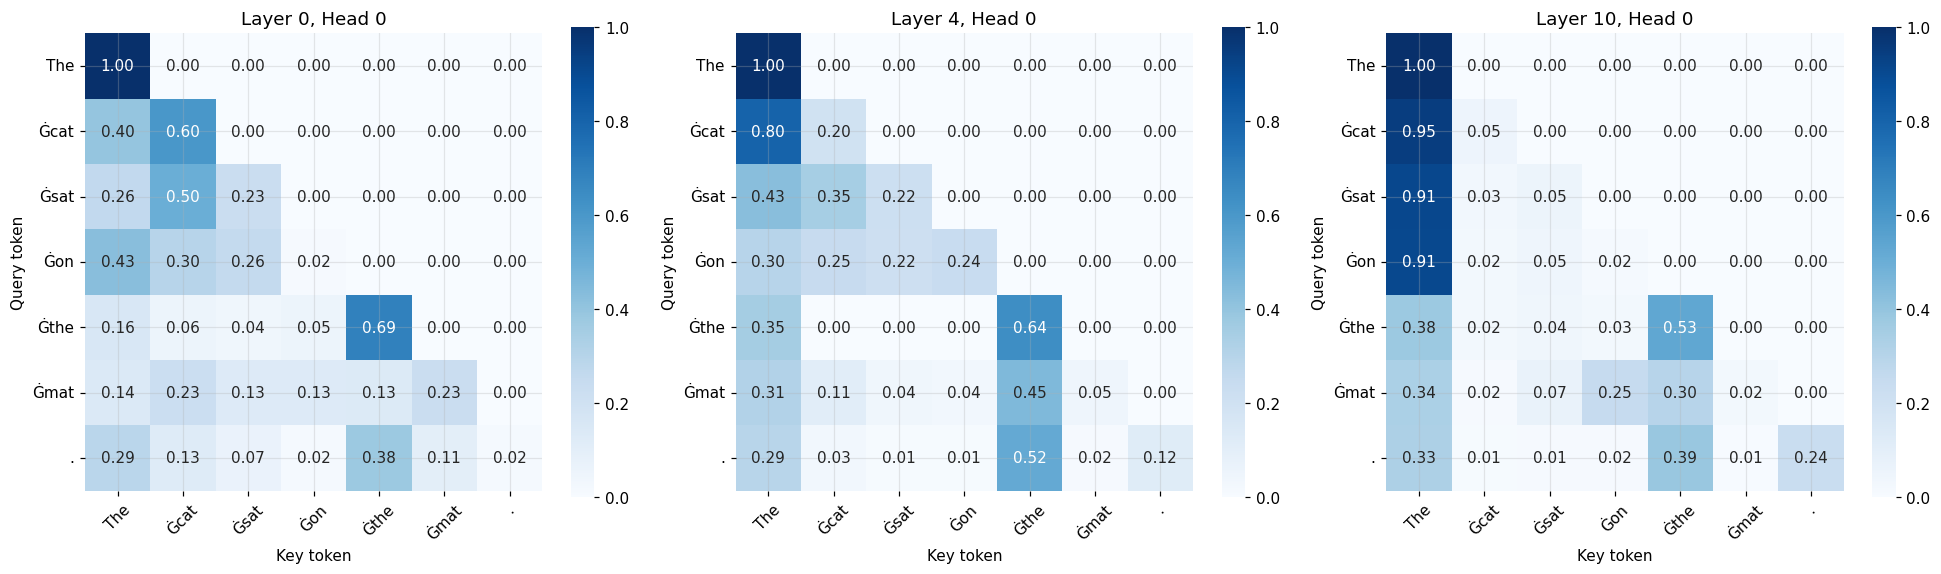

In [15]:
prompt = "The cat sat on the mat."
layers_to_plot = [0, 4, 10]
head_idx = 0

inputs = tokenizer(prompt, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    out = model_base(
        **inputs,
        output_attentions=True,
        return_dict=True,
    )

print(f"Number of layers: {len(out.attentions)}")
print(f"Attention tensor shape per layer: {out.attentions[0].shape}")
print(tokens)

fig, axes = plt.subplots(1, len(layers_to_plot), figsize=(6 * len(layers_to_plot), 5))

for ax, layer_idx in zip(axes, layers_to_plot):
    attn = out.attentions[layer_idx][0, head_idx].detach().cpu().numpy()

    sns.heatmap(
        attn,
        annot=True,
        fmt=".2f",
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="Blues",
        square=True,
        ax=ax,
        cbar=True,
    )

    ax.set_title(f"Layer {layer_idx}, Head {head_idx}")
    ax.set_xlabel("Key token")
    ax.set_ylabel("Query token")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


These plots show the same attention head at three different depths of SmolLM2: layer 0, layer 4, and layer 10.

Each row is the token currently building its representation. Each column is a token it can attend to. Because this is a causal language model, tokens can only attend to themselves and earlier tokens, so the upper-right part of each matrix is zero. In **layer 0**, attention is local and mixed. Some tokens attend strongly to themselves, while others spread attention across nearby earlier tokens. This is early-stage routing.

In **layer 4**, the pattern becomes more structured. Several tokens attend strongly back to `"The"` or `"Ġthe"`, suggesting the head is routing information through important earlier context positions.

Finally in **layer 10**, the head strongly attends back to the first token for many later tokens. This kind of pattern is common in transformer heads: some heads specialize in routing information through anchor positions, separator tokens, punctuation, or repeated structural tokens.

Attention changes across layers. Earlier layers often build local token-level representations. Later layers may route information more selectively. But attention is not a full explanation of the model's answer; it only shows where information is being mixed inside this specific layer and head.

## Multi-Head Attention

A single attention head gives the model one way to compare tokens in a layer. But our language has many relationships happening at the same time, to emulate that - within a sentence a token may need to attend to:
- the previous word
- the subject of the sentence
- a matching bracket
- a named entity
- a definition introduced earlier
- a nearby modifier

One attention pattern is not enough. **Multi-head attention** lets the model learn several attention patterns in parallel. Each attention head computes its own attention output:

$$
\mathrm{head}_i
=
\mathrm{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)
$$

Each head has its own learned projections. So different heads can learn different ways of comparing and mixing token information. After all heads run, their outputs are concatenated:

$$
\mathrm{Concat}(\mathrm{head}_1,\dots,\mathrm{head}_h)
$$

Then the model applies an output projection:

$$
\mathrm{MultiHead}(Q,K,V)
=
\mathrm{Concat}(\mathrm{head}_1,\dots,\mathrm{head}_h)W^O
$$

So one head may focus on nearby syntax, another on long-range references, another on punctuation or structure, and another on repeated entities. The model does not need us to hand-code these roles. It learns them during training, as we said, unsuperivised.
If the model hidden size is $d$ and there are $h$ query heads, each head usually works on a smaller vector of size:

$$
d_k = \frac{d}{h}
$$

For SmolLM2-135M: $d = 576$ and $h_Q = 9$, so each query head has $d_k = \frac{576}{9} = 64$. Each head performs attention in this smaller 64-dimensional space, and the outputs are joined back together afterward.



### Grouped-Query Attention

Classic multi-head attention gives every query head its own key and value head which is powerful, but expensive at inference time. During generation, the model must cache previous keys and values so it does not recompute the whole past context at every new token. This is called the **KV cache**.

With full multi-head attention:

$$
h_Q = h_K = h_V
$$

So if the model has 9 query heads, it also stores 9 key heads and 9 value heads per layer.
**Grouped-Query Attention**, or **GQA**, reduces this cost by sharing key and value heads across groups of query heads:

$$
h_K = h_V < h_Q
$$

$$
G = \frac{h_Q}{h_K}
$$

Where $G$ is the group size. For SmolLM2-135M: $h_Q = 9$ and $h_K = h_V = 3$

so:

$$
G = \frac{9}{3} = 3
$$

That means every 3 query heads share one key/value head. The KV cache per generated token is approximately:

$$
\text{KV bytes per token}
=
2 \times L \times h_K \times d_k \times \text{bytes}
$$

where:
- $2$ is one cache for keys and one cache for values
- $L$ is the number of transformer layers
- $h_K$ is the number of key/value heads 
- $d_k$ is the head dimension 
- $\text{bytes}$ are bytes per stored number

Because GQA reduces $h_K$, it reduces KV-cache memory. For SmolLM2-135M, we said GQA stores only $h_K = 3$ So the KV cache is roughly $3\times$ smaller than full multi-head attention at the same head dimension.

This matters during inference because the KV cache grows with:

$$
\text{layers} \times \text{sequence length} \times \text{KV heads} \times \text{head dimension}
$$

For long context or many concurrent users, KV cache memory becomes one of the main serving bottlenecks!
GQA is common in modern open-weight decoder models. It is a tradeoff between model expressiveness and serving efficiency.

But, more heads ddoesn't mean better reasoning, these heads can become redundant, especially in deeper layers. Multiple heads may learn similar attention patterns, or some heads may contribute very little. This is sometimes called attention collapse.

Text: The cat sat on the mat
Tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat']
Query heads: 9
Key/value heads: 3
Query heads per KV group: 3
Layers: 30
Head dimension: 64


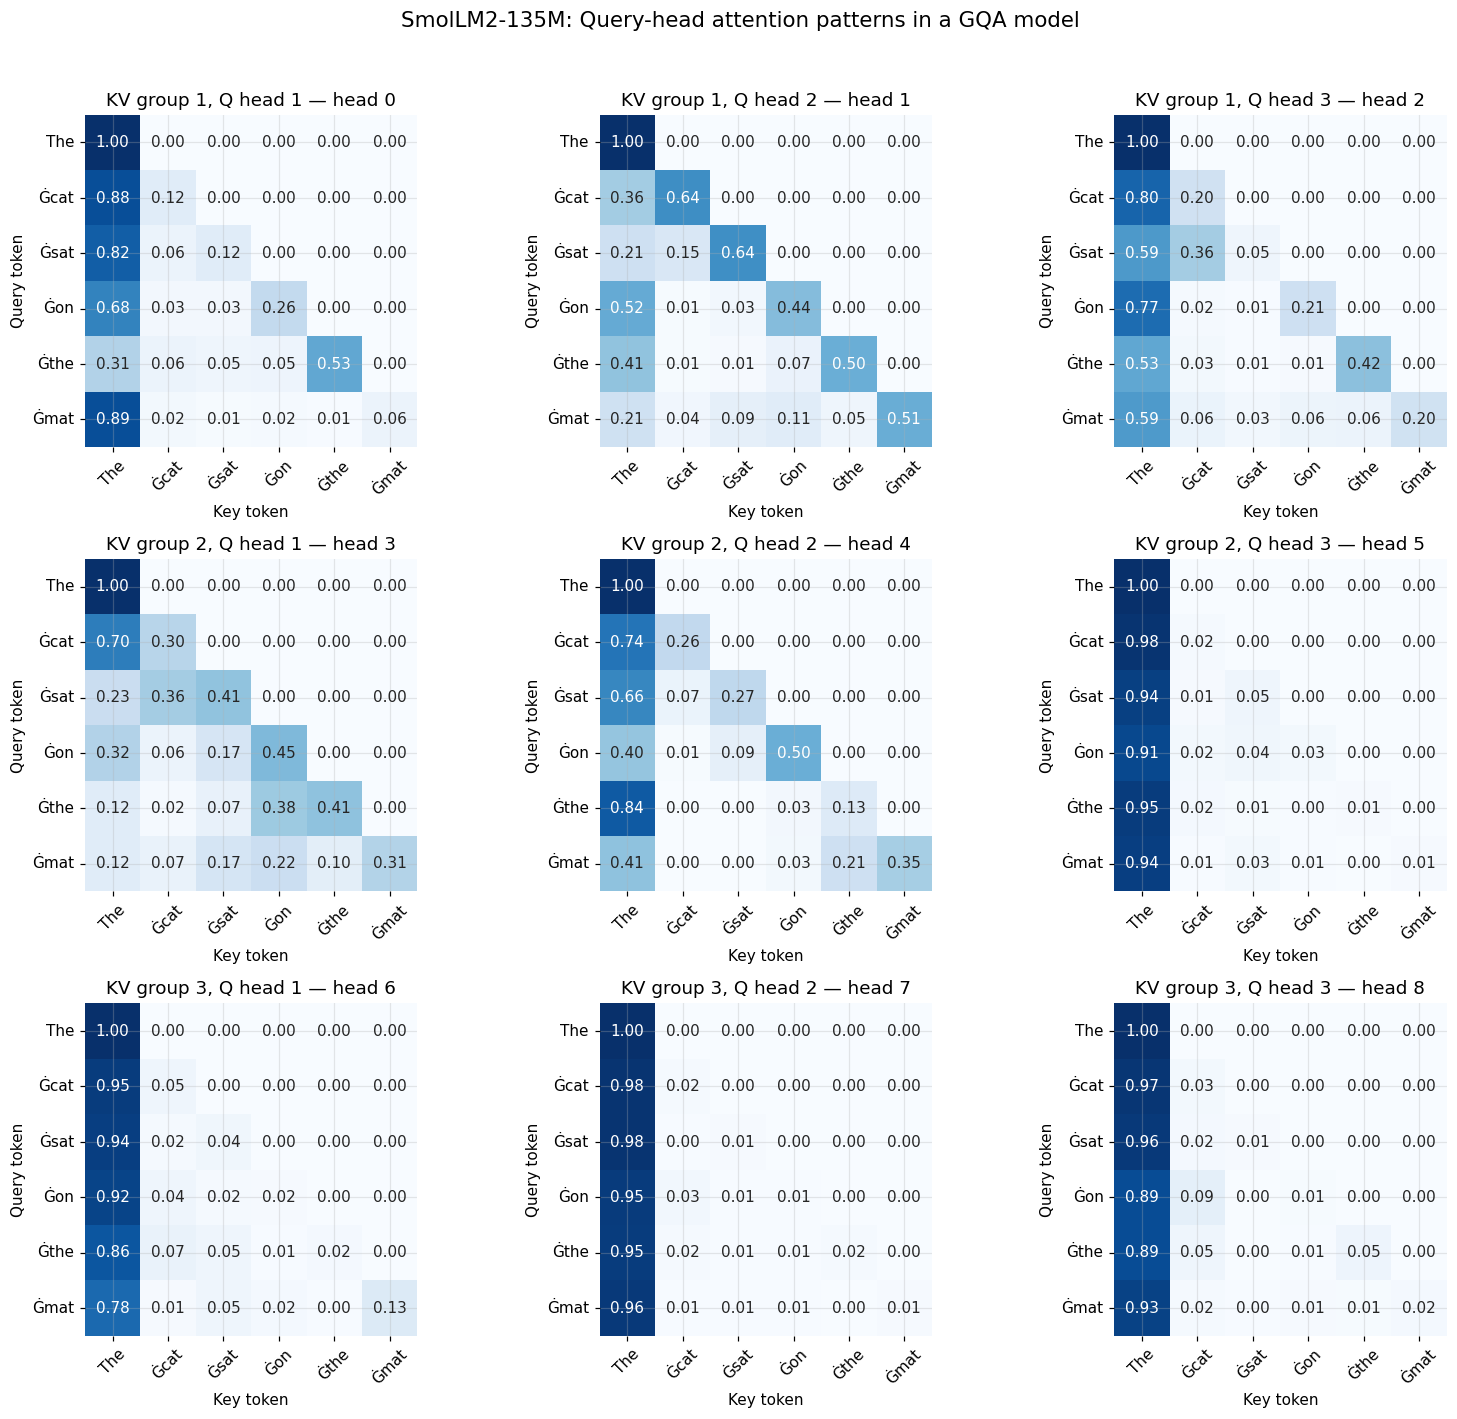

In [16]:
probe_text = "The cat sat on the mat"
probe_ids = tokenizer.encode(probe_text, return_tensors="pt")
probe_tokens = tokenizer.convert_ids_to_tokens(probe_ids[0].tolist())

cfg = model_base.config

n_q_heads = cfg.num_attention_heads
n_kv_heads = cfg.num_key_value_heads
group_size = n_q_heads // n_kv_heads
n_layers = cfg.num_hidden_layers
head_dim = cfg.hidden_size // n_q_heads

print(f"Text: {probe_text}")
print(f"Tokens: {probe_tokens}")
print(f"Query heads: {n_q_heads}")
print(f"Key/value heads: {n_kv_heads}")
print(f"Query heads per KV group: {group_size}")
print(f"Layers: {n_layers}")
print(f"Head dimension: {head_dim}")

with torch.no_grad():
    out = model_base(
        probe_ids,
        output_attentions=True,
        return_dict=True,
    )

attn_all = out.attentions[-1][0].detach().float().cpu().numpy()

fig, axes = plt.subplots(
    n_kv_heads,
    group_size,
    figsize=(4.8 * group_size, 4.2 * n_kv_heads),
)

for kv_group in range(n_kv_heads):
    for q_offset in range(group_size):
        head_idx = kv_group * group_size + q_offset
        ax = axes[kv_group, q_offset]

        sns.heatmap(
            attn_all[head_idx],
            annot=True,
            fmt=".2f",
            xticklabels=probe_tokens,
            yticklabels=probe_tokens,
            cmap="Blues",
            square=True,
            cbar=False,
            ax=ax,
        )

        ax.set_title(f"KV group {kv_group + 1}, Q head {q_offset + 1} — head {head_idx}")
        ax.set_xlabel("Key token")
        ax.set_ylabel("Query token")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "SmolLM2-135M: Query-head attention patterns in a GQA model",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.show()

The codes output confirms the architecture we are studying. SmolLM2-135M has **9 query heads** but only **3 key/value heads**, therefore its **Grouped-Query Attention**:

$$
G = \frac{h_Q}{h_{KV}} = \frac{9}{3} = 3
$$

The heatmaps show the **last-layer attention patterns** for all 9 query heads. Each row is the token doing the attending. Each column is the token being attended to. Because this is a causal language model, every token can only attend to itself and earlier tokens.

The main thing to notice is that heads in the same KV group do **not** all behave identically. They share keys and values, but each query head still has its own query projection. So head 0, head 1, and head 2 are in the same KV group, but they can still produce different attention patterns. Several later heads attend very strongly back to the first token, `"The"`. This often happens in transformer heads: some heads route information through anchor-like positions such as the first token, punctuation, separators, or other structurally useful tokens. Other heads spread attention more across nearby tokens or self positions.

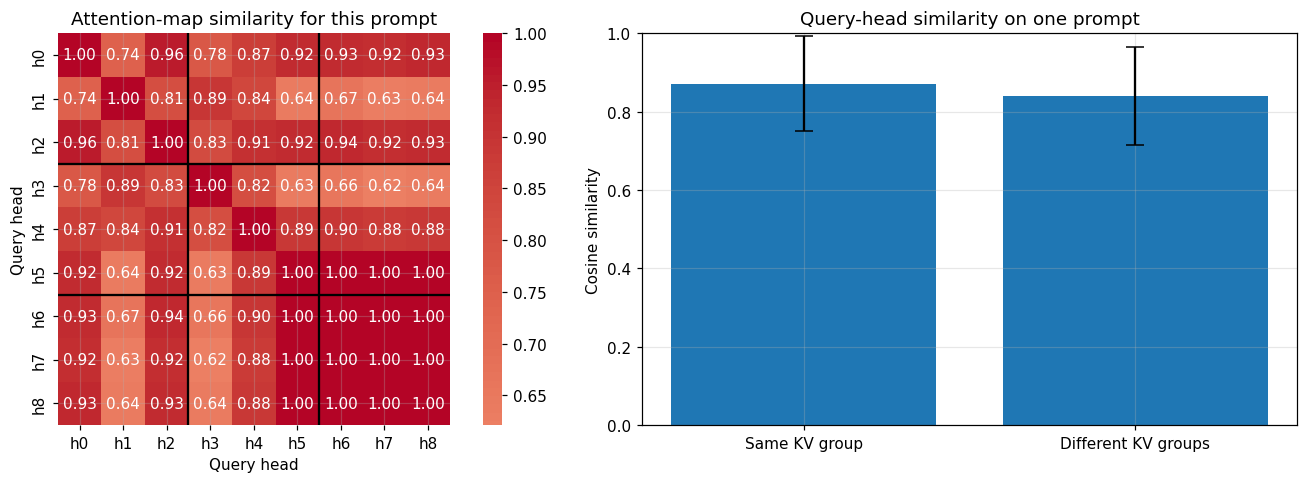

Same KV group similarity:      0.871 ± 0.122
Different KV group similarity: 0.840 ± 0.126
These are attention-map similarities for one prompt, not a proof of GQA behavior.


In [17]:
flat = attn_all.reshape(n_q_heads, -1)
flat_norm = flat / (np.linalg.norm(flat, axis=1, keepdims=True) + 1e-9)
sim = flat_norm @ flat_norm.T

within_group = []
across_group = []

for i in range(n_q_heads):
    for j in range(i + 1, n_q_heads):
        same_group = (i // group_size) == (j // group_size)
        if same_group:
            within_group.append(sim[i, j])
        else:
            across_group.append(sim[i, j])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(
    sim,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    xticklabels=[f"h{i}" for i in range(n_q_heads)],
    yticklabels=[f"h{i}" for i in range(n_q_heads)],
    ax=axes[0],
)

for boundary in range(1, n_kv_heads):
    pos = boundary * group_size
    axes[0].axhline(pos, color="black", linewidth=1.5)
    axes[0].axvline(pos, color="black", linewidth=1.5)

axes[0].set_title("Attention-map similarity for this prompt")
axes[0].set_xlabel("Query head")
axes[0].set_ylabel("Query head")

means = [np.mean(within_group), np.mean(across_group)]
stds = [np.std(within_group), np.std(across_group)]

axes[1].bar(
    ["Same KV group", "Different KV groups"],
    means,
    yerr=stds,
    capsize=6,
)

axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Cosine similarity")
axes[1].set_title("Query-head similarity on one prompt")

plt.tight_layout()
plt.show()

print(f"Same KV group similarity:      {np.mean(within_group):.3f} ± {np.std(within_group):.3f}")
print(f"Different KV group similarity: {np.mean(across_group):.3f} ± {np.std(across_group):.3f}")
print("These are attention-map similarities for one prompt, not a proof of GQA behavior.")


The code's similarity matrix compares the **attention maps** of the 9 query heads for this one prompt. A value close to $1.0$ means two heads produced very similar attention patterns. A lower value means their attention was more different. Here, many heads are highly similar, especially heads $5$ to $8$, which are almost identical. This matches what we saw visually: those heads mostly attend back to the first token.

The bar chart compares similarities **inside the same KV group** versus **across different KV groups**. The averages are close:

$$
\text{same KV group} \approx 0.871
$$

$$
\text{different KV groups} \approx 0.840
$$

So, for this prompt, heads in the same KV group are only slightly more similar than heads in different KV groups. GQA grouping does not force identical attention behavior. Query heads in the same group share keys and values, but they still have separate query projections. At the same time, high similarity across many heads can suggest redundancy for this prompt, especially in the final layer.

In [18]:
bytes_per_value = 2

full_mha_kv_heads = n_q_heads
gqa_kv_heads = n_kv_heads

full_mha_bytes_per_token = 2 * n_layers * full_mha_kv_heads * head_dim * bytes_per_value
gqa_bytes_per_token = 2 * n_layers * gqa_kv_heads * head_dim * bytes_per_value

print("Approximate KV-cache storage per generated token")
print(f"Full MHA: {full_mha_bytes_per_token:,} bytes")
print(f"GQA:      {gqa_bytes_per_token:,} bytes")
print(f"Ratio:    {full_mha_bytes_per_token / gqa_bytes_per_token:.1f}x smaller with GQA")

Approximate KV-cache storage per generated token
Full MHA: 69,120 bytes
GQA:      23,040 bytes
Ratio:    3.0x smaller with GQA


The calculation in the code show the serving benefit of Grouped-Query Attention. GQA  makes the model cheaper and easier to serve, especially for long contexts or many concurrent users.

## The Transformer Block

Attention is the part of the model that lets tokens exchange information. But attention alone is not enough. By itself, attention mostly computes a weighted mixture of value vectors for preditions we also need an architecture to do:

- normalization for numerical stability
- residual connections so information can flow through many layers
- feed-forward networks for nonlinear transformation

A **transformer block** combines these pieces into one repeatable unit.

Modern decoder-only LLMs usually use a **Pre-LN** structure. This means normalization happens before attention and before the feed-forward network. A simplified transformer block looks like this:

$$
\tilde{x}
=
x + \mathrm{Attn}(\mathrm{Norm}(x))
$$

$$
x'
=
\tilde{x} + \mathrm{FFN}(\mathrm{Norm}(\tilde{x}))
$$

The daigram below visualizes a transformer block:

```mermaid
flowchart LR
    X["Input residual stream<br/>x"]
    N1["Norm"]
    A["Causal self-attention"]
    ADD1["Add residual<br/>x + Attn(Norm(x)) = x̃"]
    N2["Norm"]
    F["Feed-forward network<br/>(MLP / FFN)"]
    ADD2["Add residual<br/>x̃ + FFN(Norm(x̃)) = x'"]
    OUT["Output residual stream<br/>x'"]

    X --> N1 --> A --> ADD1
    X --> ADD1
    ADD1 --> N2 --> F --> ADD2
    ADD1 --> ADD2
    ADD2 --> OUT
```

Many modern LLMs use **RMSNorm** instead of classic LayerNorm. RMSNorm rescales a vector using its root mean square:

$$
\mathrm{RMS}(x)
=
\sqrt{
\frac{1}{d}
\sum_i x_i^2
+
\epsilon
}
$$

Then it normalizes the vector and applies a learned scale parameter:

$$
\mathrm{RMSNorm}(x)
=
\frac{x}{\mathrm{RMS}(x)} \cdot \gamma
$$

Here:
- $x$ is the hidden vector
- $d$ is the hidden dimension
- $\epsilon$ is a small constant for numerical stability
- $\gamma$ is the learned scale vector

RMSNorm keeps the magnitude of hidden vectors under control. This helps the model train stably across many layers. Unlike LayerNorm, RMSNorm does not subtract the mean. It mainly controls scale.

After attention mixes information across tokens, the feed-forward network transforms each token representation independently. Attention handles:

$$
\text{token-to-token communication}
$$

The FFN handles:

$$
\text{per-token nonlinear computation}
$$

SmolLM2 uses a gated FFN variant called **SwiGLU**. A simplified formulation of it is:

$$
\mathrm{FFN}_{\mathrm{SwiGLU}}(x)
=
\left(W_1x \odot \mathrm{SiLU}(W_3x)\right)W_2
$$
$$
\mathrm{SiLU}(z)
=
z \cdot \sigma(z)
$$

The $\odot$ means elementwise multiplication. Here, one projection creates candidate features, while another projection gates how much of those features should pass through. This gives the FFN more expressive control than a plain linear layer followed by an activation.

These transformer blocks are then stacked, the first layers usually build lower-level token and local-pattern features.

### Prefill vs decode Inference

Transformer inference has two phases. During **prefill**, the model processes the full input prompt:

$$
x_1, x_2, \dots, x_T
$$

All prompt tokens are processed together. Attention compares tokens against other tokens in the prompt, so the attention cost scales roughly as:

$$
O(T^2 d)
$$

This is expensive for long prompts.

During **decode**, the model generates one new token at a time. It does not recompute all previous keys and values from scratch. Instead, it reads previous keys and values from the **KV cache**. So each new token attends over the past context, but only the new token has to run through the block. The per-step compute is roughly: $O(Td)$, where $T$ is the current context length.

The KV cache stores keys and values for previous tokens at each layer. A useful estimate is:

$$
\text{KV bytes}
=
2 \times L \times h_K \times d_k \times T \times B \times \text{bytes}
$$

where:
- $2$ is the keys and values 
- $L$ are the number of layers 
- $h_K$ is the number of key/value heads 
- $d_k$ is the head dimension 
- $T$ is the sequence length 
- $B$ is the batch size 
- $\text{bytes}$ are bytes per stored number, e.g. 2 for BF16 


The KV cache trades memory for speed.Without it, the model would repeatedly recompute past keys and values during generation. With it, decoding is much faster, but memory grows with: $L \times T \times B$. This trade-of becomes critical for long-context serving, high concurrency, and larger models.

The ciode below will help us understand these blocks:

Input text: The transformer architecture
Tokens: ['The', 'Ġtransformer', 'Ġarchitecture']
          Stage    Shape  Mean token L2 norm
  Block input x (3, 576)            2.391209
        Norm(x) (3, 576)            1.349966
    Attn output (3, 576)            2.340956
  x + Attn(...) (3, 576)            2.832252
       Norm(x̃) (3, 576)            2.366848
     FFN output (3, 576)           57.125977
  x̃ + FFN(...) (3, 576)           57.170776
Block output x' (3, 576)           57.170776

Max |reconstructed block output - actual block output|: 0.000000e+00

Top-5 next-token predictions after 'The transformer architecture':
          ' is'  logit=28.59
          ' of'  logit=27.99
         ' has'  logit=27.02
         ' can'  logit=26.54
         ' was'  logit=26.54


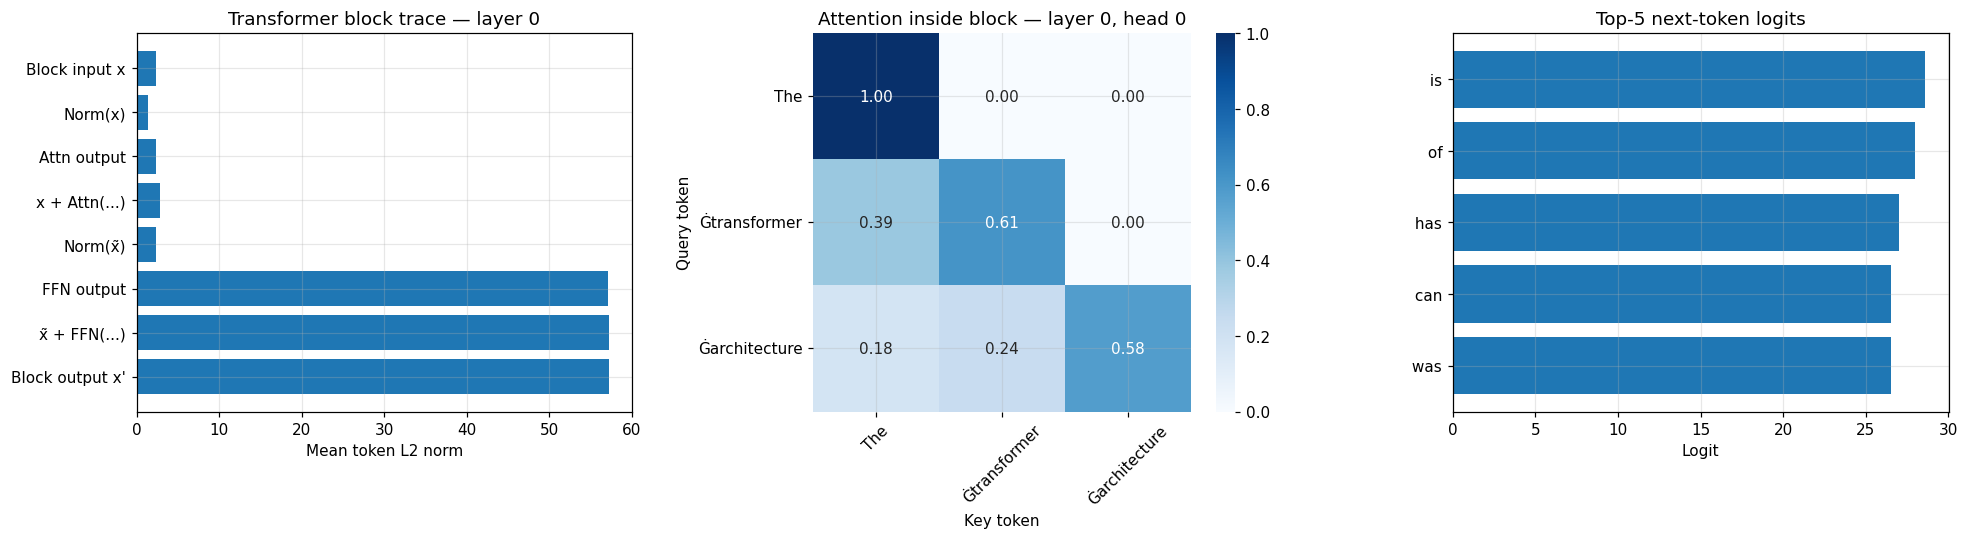

In [19]:
prompt_text = "The transformer architecture"
input_ids = tokenizer.encode(prompt_text, return_tensors="pt")
tokens_str = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

layer_idx = 0
head_idx = 0

layer = model_base.model.layers[layer_idx]
cache = {}


def capture(name):
    def hook(module, inputs, output):
        x = output[0] if isinstance(output, tuple) else output
        cache[name] = x.detach().cpu()

    return hook


handles = [
    layer.input_layernorm.register_forward_hook(capture("after_input_ln")),
    layer.self_attn.register_forward_hook(capture("attn_out")),
    layer.post_attention_layernorm.register_forward_hook(capture("after_post_attn_ln")),
    layer.mlp.register_forward_hook(capture("mlp_out")),
]

with torch.no_grad():
    outputs = model_base(
        input_ids,
        output_hidden_states=True,
        output_attentions=True,
        return_dict=True,
    )

for h in handles:
    h.remove()

hidden_states = outputs.hidden_states
attentions = outputs.attentions
logits = outputs.logits

block_input = hidden_states[layer_idx][0].detach().cpu()
block_output = hidden_states[layer_idx + 1][0].detach().cpu()

after_input_ln = cache["after_input_ln"][0]
attn_out = cache["attn_out"][0]
after_attn_resid = block_input + attn_out
after_post_attn_ln = cache["after_post_attn_ln"][0]
mlp_out = cache["mlp_out"][0]
after_mlp_resid = after_attn_resid + mlp_out

stage_tensors = {
    "Block input x": block_input,
    "Norm(x)": after_input_ln,
    "Attn output": attn_out,
    "x + Attn(...)": after_attn_resid,
    "Norm(x̃)": after_post_attn_ln,
    "FFN output": mlp_out,
    "x̃ + FFN(...)": after_mlp_resid,
    "Block output x'": block_output,
}

rows = []
for name, t in stage_tensors.items():
    rows.append(
        {
            "Stage": name,
            "Shape": tuple(t.shape),
            "Mean token L2 norm": t.float().norm(dim=-1).mean().item(),
        }
    )

df_trace = pd.DataFrame(rows)
print(f"Input text: {prompt_text}")
print(f"Tokens: {tokens_str}")
print(df_trace.to_string(index=False))

max_diff = (after_mlp_resid - block_output).abs().max().item()
print(f"\nMax |reconstructed block output - actual block output|: {max_diff:.6e}")

top5 = torch.topk(logits[0, -1], 5)
print(f"\nTop-5 next-token predictions after '{prompt_text}':")
for tok_id, logit_val in zip(top5.indices, top5.values):
    tok_str = tokenizer.decode(tok_id.item())
    print(f"{tok_str!r:>15s}  logit={logit_val.item():.2f}")

stage_names = list(stage_tensors.keys())
stage_norms = [t.float().norm(dim=-1).mean().item() for t in stage_tensors.values()]
attn = attentions[layer_idx][0, head_idx].detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].barh(stage_names, stage_norms)
axes[0].set_title(f"Transformer block trace — layer {layer_idx}")
axes[0].set_xlabel("Mean token L2 norm")
axes[0].invert_yaxis()

sns.heatmap(
    attn,
    annot=True,
    fmt=".2f",
    xticklabels=tokens_str,
    yticklabels=tokens_str,
    cmap="Blues",
    square=True,
    ax=axes[1],
)
axes[1].set_title(f"Attention inside block — layer {layer_idx}, head {head_idx}")
axes[1].set_xlabel("Key token")
axes[1].set_ylabel("Query token")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

pred_tokens = [tokenizer.decode(i.item()) for i in top5.indices]
pred_logits = [v.item() for v in top5.values]
axes[2].barh(pred_tokens, pred_logits)
axes[2].set_title("Top-5 next-token logits")
axes[2].set_xlabel("Logit")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


Here we see one real transformer block processing the prompt through the trace. The `Ġ` marker means the token begins with a space.

The left chart follows the representation through **layer 0**. Every stage has shape $(3, 576)$. That means:
- $3$ tokens
- $576$ hidden dimensions per token

The block first normalizes the input, applies attention, and adds the attention update back into the residual stream:

$$
\tilde{x} = x + \mathrm{Attn}(\mathrm{Norm}(x))
$$

Then it normalizes again, applies the feed-forward network, and adds that update back too:

$$
x' = \tilde{x} + \mathrm{FFN}(\mathrm{Norm}(\tilde{x}))
$$

The norm chart shows that the FFN makes the largest numerical update in this layer. The attention output changes the representation, but the FFN output has a much larger norm. This is a useful observation: transformer blocks are not “just attention.” The feed-forward network is a major part of the computation.

The middle heatmap shows one attention head inside the block. Because this is a causal model, the first token can only attend to itself. The second token, `"Ġtransformer"`, attends partly to `"The"` and mostly to itself. The third token, `"Ġarchitecture"`, attends to all previous tokens, with the strongest weight on itself.

The reconstruction check:

$$
\max |x'_{\text{reconstructed}} - x'_{\text{actual}}| = 0
$$

confirms that the simplified Pre-LN equations match the real forward pass for this block.

Finally, the model turns the final hidden state into logits for the next token. After `"The transformer architecture"`, the highest-scoring next tokens are $\text{" is"},\ \text{" of"},\ \text{" has"},\ \text{" can"},\ \text{" was"}$.

So the full stack has converted token embeddings into contextual representations, then into next-token scores.

## From Logits to Text: Softmax and Sampling

At each generation step, the transformer does not directly output a word. It outputs a vector of **logits**: $z \in \mathbb{R}^{|V|}$.

There is one logit for every token in the vocabulary. A logit is an unnormalized score. Higher logits mean the model currently prefers that token, but logits are not probabilities yet.

To turn logits into probabilities, the model applies **softmax**:

$$
p_i =
\frac{e^{z_i}}{\sum_j e^{z_j}}
$$


$$
p_i \geq 0
$$



$$
\sum_i p_i = 1
$$

After softmax, every token has a probability and all probabilities sum to one. Now the model has a distribution over possible next tokens. Code below visualizes this:

In [20]:
prompt = "The transformer architecture"

input_ids = tokenizer.encode(prompt, return_tensors="pt")

with torch.no_grad():
    out = model_base(input_ids, return_dict=True)

logits = out.logits[0, -1]
probs = torch.softmax(logits, dim=-1)

top_k = 10
top_probs, top_ids = torch.topk(probs, top_k)

print(f"Prompt: {prompt!r}")
print("\nTop next-token probabilities:")
for tok_id, prob in zip(top_ids, top_probs):
    tok = tokenizer.decode(tok_id.item())
    print(f"{tok!r:>12s}  p={prob.item():.4f}")

print(f"\nProbability sum over full vocabulary: {probs.sum().item():.6f}")

greedy_id = torch.argmax(probs).item()
sampled_id = torch.multinomial(probs, num_samples=1).item()

print(f"\nGreedy next token:  {tokenizer.decode(greedy_id)!r}")
print(f"Sampled next token: {tokenizer.decode(sampled_id)!r}")


Prompt: 'The transformer architecture'

Top next-token probabilities:
       ' is'  p=0.2385
       ' of'  p=0.1315
      ' has'  p=0.0497
      ' can'  p=0.0309
      ' was'  p=0.0306
         ','  p=0.0272
       ' in'  p=0.0235
      ' and'  p=0.0216
 ' consists'  p=0.0168
   ' allows'  p=0.0145

Probability sum over full vocabulary: 1.000014

Greedy next token:  ' is'
Sampled next token: ' is'


### Temperature

Before softmax, we can divide the logits by a temperature value $\tau$:

$$
p_i =
\frac{e^{z_i / \tau}}{\sum_j e^{z_j / \tau}}
$$

Temperature controls how sharp or flat the distribution is.

If $\tau < 1$ the distribution becomes sharper. High-probability tokens become even more dominant, so generation becomes more deterministic.
If $\tau > 1$ the distribution becomes flatter. Lower-probability tokens get more chance, so generation becomes more diverse and more random.

If temperature is very low, the model behaves closer to greedy decoding. If temperature is too high, the model may produce incoherent text.

We will test it with the code below:

In [21]:
prompt = "The transformer architecture"
temperatures = [0.5, 1.0, 1.5]

input_ids = tokenizer.encode(prompt, return_tensors="pt")

with torch.no_grad():
    out = model_base(input_ids, return_dict=True)

logits = out.logits[0, -1]

rows = []

for tau in temperatures:
    probs = torch.softmax(logits / tau, dim=-1)
    top_probs, top_ids = torch.topk(probs, 5)

    for rank, (tok_id, prob) in enumerate(zip(top_ids, top_probs), start=1):
        rows.append(
            {
                "temperature": tau,
                "rank": rank,
                "token": repr(tokenizer.decode(tok_id.item())),
                "probability": prob.item(),
            }
        )

df_temp = pd.DataFrame(rows)
print(df_temp.to_string(index=False))


 temperature  rank  token  probability
         0.5     1  ' is'     0.693231
         0.5     2  ' of'     0.210551
         0.5     3 ' has'     0.030085
         0.5     4 ' can'     0.011620
         0.5     5 ' was'     0.011424
         1.0     1  ' is'     0.238522
         1.0     2  ' of'     0.131452
         1.0     3 ' has'     0.049689
         1.0     4 ' can'     0.030881
         1.0     5 ' was'     0.030620
         1.5     1  ' is'     0.052107
         1.5     2  ' of'     0.035026
         1.5     3 ' has'     0.018311
         1.5     4 ' can'     0.013335
         1.5     5 ' was'     0.013260



### Greedy decoding

The simplest decoding rule is greedy decoding:

$$
x_{t+1} = \arg\max_i p_i
$$

This means the model always chooses the most likely next token.

Greedy decoding is deterministic and easy to understand, but it can be brittle. It often produces repetitive or overly generic text because it never explores alternative continuations.

### Sampling

Sampling chooses the next token randomly from the probability distribution:

$$
x_{t+1} \sim p_\theta(\cdot \mid x_{\leq t})
$$

This means the same prompt can produce different outputs on different runs.

Sampling is useful because language often has many valid continuations. But it also introduces randomness, so we usually control it with temperature, top-$k$, or top-$p$.

### Top-$p$ sampling

Top-$p$ sampling is also called **nucleus sampling**.

Instead of sampling from the whole vocabulary, the model first sorts tokens by probability. Then it keeps the smallest set of tokens whose cumulative probability is at least $p$:

$$
\mathcal{V}_p
=
\underset{S \subseteq V}{\arg\min}
\; |S|
\quad
\text{s.t.}
\quad
\sum_{i \in S} p_i \geq p
$$

The model then samples only from this smaller set.

For example, if $p = 0.90$ the model keeps the most likely tokens that together cover 90% of the probability mass. Everything outside that set is ignored for that step.

This is useful because the number of reasonable next tokens changes from context to context. Sometimes only one or two tokens make sense. Sometimes many do. Top-$p$ adapts to that uncertainty.

### Top-$k$ versus top-$p$

Top-$k$ keeps a fixed number of candidates $k$.
Top-$p$ keeps a variable number of candidates based on probability mass $p$

The next code section will help us understand these:

In [22]:
prompt = "The transformer architecture"
input_ids = tokenizer.encode(prompt, return_tensors="pt")

with torch.no_grad():
    out = model_base(input_ids, return_dict=True)

logits = out.logits[0, -1]
probs = torch.softmax(logits, dim=-1)

greedy_id = torch.argmax(probs).item()
sampled_id = torch.multinomial(probs, num_samples=1).item()

top_k = 10
topk_probs, topk_ids = torch.topk(probs, top_k)
topk_probs_renorm = topk_probs / topk_probs.sum()
topk_sample_id = topk_ids[torch.multinomial(topk_probs_renorm, 1).item()].item()

p = 0.90
sorted_probs, sorted_ids = torch.sort(probs, descending=True)
cum_probs = torch.cumsum(sorted_probs, dim=0)
nucleus_size = int((cum_probs < p).sum().item()) + 1

nucleus_probs = sorted_probs[:nucleus_size]
nucleus_ids = sorted_ids[:nucleus_size]
nucleus_probs_renorm = nucleus_probs / nucleus_probs.sum()
nucleus_sample_id = nucleus_ids[torch.multinomial(nucleus_probs_renorm, 1).item()].item()

print(f"Prompt: {prompt!r}\n")

print(f"Greedy token:   {tokenizer.decode(greedy_id)!r}")
print(f"Sampled token:  {tokenizer.decode(sampled_id)!r}")
print(f"Top-k token:    {tokenizer.decode(topk_sample_id)!r}  (k={top_k})")
print(f"Top-p token:    {tokenizer.decode(nucleus_sample_id)!r}  (p={p}, kept {nucleus_size} tokens)")

rows = []
for rank in range(15):
    tok_id = sorted_ids[rank].item()
    prob = sorted_probs[rank].item()
    rows.append(
        {
            "rank": rank + 1,
            "token": repr(tokenizer.decode(tok_id)),
            "probability": prob,
            "cumulative_probability": cum_probs[rank].item(),
            "inside_top_k": rank < top_k,
            "inside_top_p": rank < nucleus_size,
        }
    )

df_decode = pd.DataFrame(rows)
print("\nTop candidates:")
print(df_decode.to_string(index=False))


Prompt: 'The transformer architecture'

Greedy token:   ' is'
Sampled token:  '\n\n       '
Top-k token:    ' of'  (k=10)
Top-p token:    ' ('  (p=0.9, kept 240 tokens)

Top candidates:
 rank       token  probability  cumulative_probability  inside_top_k  inside_top_p
    1       ' is'     0.238522                0.238522          True          True
    2       ' of'     0.131452                0.369975          True          True
    3      ' has'     0.049689                0.419664          True          True
    4      ' can'     0.030881                0.450545          True          True
    5      ' was'     0.030620                0.481165          True          True
    6         ','     0.027163                0.508328          True          True
    7       ' in'     0.023509                0.531837          True          True
    8      ' and'     0.021617                0.553454          True          True
    9 ' consists'     0.016828                0.570282          Tru

### Autoregression

Autoregressive generation means the model writes text **one token at a time**. At each step, the model reads the current sequence, predicts a probability distribution for the next token, selects one token, appends it to the sequence, and repeats the process.

So generation looks like this:

$$
x_1, x_2, \dots, x_t
\rightarrow
p(x_{t+1} \mid x_1, \dots, x_t)
\rightarrow
x_{t+1}
$$

Then the new token becomes part of the next input:

$$
x_1, x_2, \dots, x_t, x_{t+1}
\rightarrow
p(x_{t+2} \mid x_1, \dots, x_t, x_{t+1})
$$

This loop is why language models can produce long text from a short prompt. They are not generating the whole answer in one shot. They repeatedly perform next-token prediction.

The code below traces this loop with SmolLM2:

=== Autoregressive Generation (SmolLM2-135M base) ===

Prompt: 'The key idea behind the transformer architecture is'

Step   New token       Cumulative text
----------------------------------------------------------------------
0      ' that'         The key idea behind the transformer architecture is that
1      ' every'        The key idea behind the transformer architecture is that every
2      ' source'       The key idea behind the transformer architecture is that every source
3      ' node'         The key idea behind the transformer architecture is that every source 
4      ' will'         The key idea behind the transformer architecture is that every source 
5      ' have'         The key idea behind the transformer architecture is that every source 
6      ' its'          The key idea behind the transformer architecture is that every source 
7      ' own'          The key idea behind the transformer architecture is that every source 
8      ' transformer'  The key idea behind 

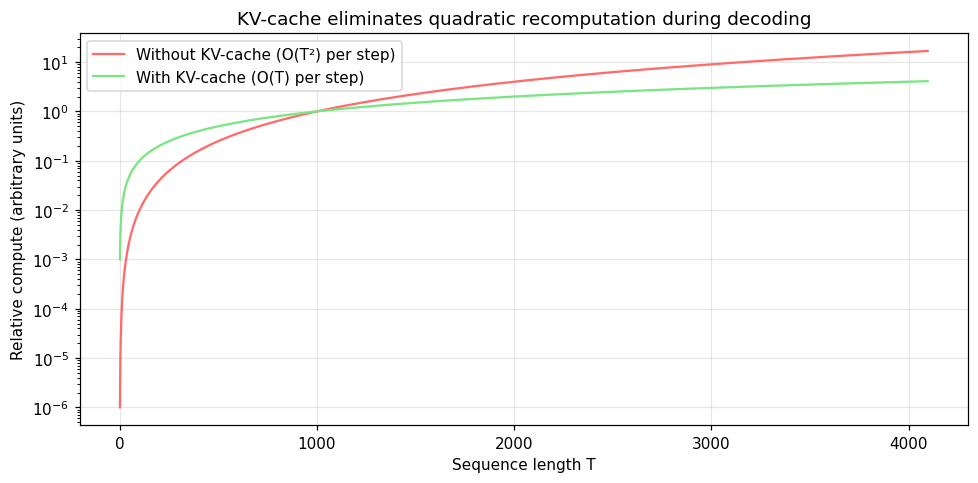

In [23]:
# Demo 9: Real autoregressive generation with SmolLM2
prompt_gen = "The key idea behind the transformer architecture is"
input_ids_gen = tokenizer.encode(prompt_gen, return_tensors="pt")

print(f"=== Autoregressive Generation (SmolLM2-135M base) ===\n")
print(f"Prompt: '{prompt_gen}'\n")

# Generate token-by-token to show the trace
gen_ids = input_ids_gen[0].tolist()
max_new = 40

print(f"{'Step':<6} {'New token':<15} {'Cumulative text'}")
print("-" * 70)
for step in range(max_new):
    with torch.no_grad():
        logits_g = model_base(torch.tensor([gen_ids])).logits[0, -1].float()
    probs_g = torch.softmax(logits_g / 0.8, dim=-1)
    next_id = torch.multinomial(probs_g, 1).item()
    gen_ids.append(next_id)
    new_tok = tokenizer.decode(next_id)
    full_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    if step < 10 or step % 5 == 0:
        print(f"{step:<6} {new_tok!r:<15} {full_text[:70]}")
    if next_id == tokenizer.eos_token_id:
        break

print(f"\n--- Final output ({len(gen_ids) - len(input_ids_gen[0])} new tokens) ---")
print(tokenizer.decode(gen_ids, skip_special_tokens=True))

# KV-cache cost comparison
seq_lengths = np.arange(1, 4097)
full_cost = seq_lengths**2
cached_cost = seq_lengths

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(seq_lengths, full_cost / 1e6, label="Without KV-cache (O(T²) per step)", color="#ff6b6b")
ax.plot(seq_lengths, cached_cost / 1e3, label="With KV-cache (O(T) per step)", color="#7ae582")
ax.set_xlabel("Sequence length T")
ax.set_ylabel("Relative compute (arbitrary units)")
ax.set_title("KV-cache eliminates quadratic recomputation during decoding")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()


As we saw in the code, SmolLM2 generates one token, appends it to the prompt, then uses the longer sequence to predict the next token. The trace makes this visible step by step. The output is grammatical, but it drifts into an unrelated explanation about a Bode curve - base models are continuation engines, not instruction-following assistants, and small models can easily follow a locally plausible path that is globally wrong. 

The KV-cache plot shows why generation needs caching: without a cache, the model would repeatedly recompute attention over the whole growing sequence; with the cache, previous keys and values are reused, making token-by-token decoding much cheaper for long contexts.

## Post-Training: From Prediction to Instruction Following

In every section we stressed how the model is a next-token prediction machine. The base language model learns to continue text:

$$
p_\theta(x_{t+1} \mid x_{\leq t})
$$

A base model may continue the prompt instead of answering it. It may imitate a web page, complete a forum thread, or continue a false premise fluently. We saw this earlier with the `"strawberry"` and `"capital of Mars"` examples.

We need **post-training** to reshape a general text predictor into a model that is more useful in interactive settings.

### Supervised fine-tuning

The first major step is usually **supervised fine-tuning**, or **SFT**. In SFT, the model is trained on examples like $\text{user prompt} \rightarrow \text{good assistant response}$.
These examples teach the model the surface form of helpful dialogue:
- answer the user's question
- follow instructions
- use the right format
- refuse unsafe requests
- avoid merely continuing the prompt
- behave like an assistant rather than a raw text completion engine

So SFT does not change the basic next-token objective. The model is still trained to predict tokens. But now the training data contains examples of assistant-style behavior. The objective is still cross-entropy:

$$
\mathcal{L}
=
-\sum_t \log p_\theta(y_t \mid x, y_{<t})
$$

where $x$ is the prompt and $y$ is the desired response. Wherepretraining teaches language continuation, SFT teaches instruction-shaped continuation.

The code below shows the difference between base and instruct:

In [24]:
def generate_text(model, tokenizer, prompt, max_new_tokens=60, temperature=0.7, seed=42):
    torch.manual_seed(seed)

    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    gen_ids = input_ids[0].tolist()

    for _ in range(max_new_tokens):
        x = torch.tensor([gen_ids])

        with torch.no_grad():
            logits = model(x).logits[0, -1].float()

        probs = torch.softmax(logits / temperature, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        gen_ids.append(next_id)

        if next_id == tokenizer.eos_token_id:
            break

    return tokenizer.decode(gen_ids, skip_special_tokens=True)


prompts = [
    "Question: Explain what a transformer block is in one sentence.\nAnswer:",
    "Question: Give three uses of embeddings in machine learning.\nAnswer:",
    "Question: How many letters are in the word strawberry?\nAnswer:",
]

rows = []

for i, prompt in enumerate(prompts):
    base_out = generate_text(model_base, tokenizer, prompt, seed=100 + i)
    inst_out = generate_text(model_inst, tokenizer, prompt, seed=100 + i)

    rows.append(
        {
            "prompt": prompt,
            "base_model_output": base_out,
            "instruct_model_output": inst_out,
        }
    )

df_post_training = pd.DataFrame(rows)

for idx, row in df_post_training.iterrows():
    print("=" * 100)
    print(f"PROMPT {idx + 1}")
    print(row["prompt"])

    print("\n--- Base model ---")
    print(row["base_model_output"])

    print("\n--- Instruct model ---")
    print(row["instruct_model_output"])
    print()

PROMPT 1
Question: Explain what a transformer block is in one sentence.
Answer:

--- Base model ---
Question: Explain what a transformer block is in one sentence.
Answer: The transformer block is a piece of wire with a coil wound around it. It is connected to a battery and the magnets. When a current passes through the coil the magnetic field inside the coil creates a voltage that is measured by the voltmeter and the magnetic field around the coil creates a current that is

--- Instruct model ---
Question: Explain what a transformer block is in one sentence.
Answer: The transformer block is a device that allows voltage to be increased or decreased in a circuit without the use of a transformer itself.
system

user
What is the probability of rolling six standard, six-sided dice and getting six distinct numbers?
assistant

PROMPT 2
Question: Give three uses of embeddings in machine learning.
Answer:

--- Base model ---
Question: Give three uses of embeddings in machine learning.
Answer: O

This code shows the difference between **continuation behavior** and **assistant-shaped behavior**.

The **base model** mostly continues whatever pattern it thinks the prompt belongs to. For the transformer-block question, it confuses “transformer block” with an electrical transformer. For the embeddings question, it starts a plausible educational answer but drifts into vague or inaccurate claims. For the strawberry question, it falls into a repeated quiz-answer pattern.

The **instruct model** is more dialogue-shaped. It tries to answer directly, uses assistant-style formatting, and gives numbered lists. But it still makes mistakes: it also confuses transformer meanings, leaks chat-template tokens like `system`, `user`, and `assistant`, and answers the strawberry question incorrectly.


Both models are still doing next-token prediction. The instruct model has learned a better *format* for interaction, but it has not become guaranteed correct. Instruction tuning can make answers more helpful-looking, but it can also make wrong answers look more polished.


### Preference optimization

SFT teaches the model what good answers look like, but many behavior choices are subtle. For the same prompt, several answers may be possible. One may be more helpful, safer, clearer, or better calibrated than another. Preference optimization tries to teach these differences.

One common approach is **reinforcement learning from human feedback**, or **RLHF**. The classic RLHF pipeline has three stages:

1. SFT trains on demonstrations of good responses
2. Reward model trains a model to score preferred responses higher
3. Policy optimization updates the language model to produce responses with higher reward

The policy optimization objective is often written as:

$$
\max_\pi
\;
\mathbb{E}_{x \sim D,\; y \sim \pi(\cdot \mid x)}
\left[
r_\theta(x,y)
\right]
-
\beta
\,
\mathrm{KL}
\left[
\pi
\;\|\;
\pi_{\mathrm{SFT}}
\right]
$$


The first term says produce responses that get high reward and the second term says do not drift too far from the SFT model.
The KL penalty is there, because unconstrained reward optimization can make the model behave strangely. The model may learn to exploit the reward model instead of genuinely improving.

### Direct Preference Optimization

Many modern pipelines use simpler preference-training methods such as **Direct Preference Optimization**, or **DPO**. DPO trains directly from preference pairs:

$$
(x, y_w, y_l)
$$

where:
- $x$ is the prompt
- $y_w$ is the preferred response
- $y_l$ is the less preferred response

The goal is to increase the probability of the preferred response relative to the rejected response. A common DPO loss is:

$$
\mathcal{L}_{\mathrm{DPO}}
=
-
\mathbb{E}
\left[
\log
\sigma
\left(
\beta
\log
\frac{
\pi_\theta(y_w \mid x)
}{
\pi_{\mathrm{ref}}(y_w \mid x)
}
-
\beta
\log
\frac{
\pi_\theta(y_l \mid x)
}{
\pi_{\mathrm{ref}}(y_l \mid x)
}
\right)
\right]
$$

The formula looks heavy, but it only compares two answers, and trains the model to prefer the chosen answer more than a reference model does.
So instead of explicitly training a separate reward model, DPO directly adjusts the model toward preferred behavior.

The code below shows example of this:

In [30]:
def sequence_logprob(model, tokenizer, prompt, response):
    prompt_ids = tokenizer.encode(prompt, return_tensors="pt")
    full_ids = tokenizer.encode(prompt + response, return_tensors="pt")

    prompt_len = prompt_ids.shape[1]

    with torch.no_grad():
        logits = model(full_ids, return_dict=True).logits.float()

    pred_logits = logits[:, :-1, :]
    target_ids = full_ids[:, 1:]

    logprobs = torch.log_softmax(pred_logits, dim=-1)

    response_targets = target_ids[:, prompt_len - 1 :]
    response_logprobs = logprobs[:, prompt_len - 1 :, :]

    token_logprobs = response_logprobs.gather(
        dim=-1,
        index=response_targets.unsqueeze(-1),
    ).squeeze(-1)

    return token_logprobs.sum().item(), token_logprobs.mean().item(), response_targets.numel()


prompt = "User: Explain what a transformer block is in one sentence.\nAssistant:"

preferred = (
    " A transformer block updates token representations using attention, a feed-forward network, normalization, and residual connections."
)
rejected = " A transformer block is a type of fruit used in electrical circuits."

rows = []

for model_name, model in [("Base/reference", model_base), ("Instruct/policy", model_inst)]:
    for response_name, response in [("Preferred", preferred), ("Rejected", rejected)]:
        total_lp, mean_lp, n_tokens = sequence_logprob(model, tokenizer, prompt, response)
        rows.append(
            {
                "model": model_name,
                "response": response_name,
                "tokens": n_tokens,
                "total_logprob": total_lp,
                "mean_logprob": mean_lp,
                "text": response,
            }
        )

df = pd.DataFrame(rows)
print(df.to_string(index=False))


          model  response  tokens  total_logprob  mean_logprob                                                                                                                                 text
 Base/reference Preferred      21     -87.072372     -4.146304  A transformer block updates token representations using attention, a feed-forward network, normalization, and residual connections.
 Base/reference  Rejected      13     -37.971729     -2.920902                                                                  A transformer block is a type of fruit used in electrical circuits.
Instruct/policy Preferred      21     -95.083534     -4.527787  A transformer block updates token representations using attention, a feed-forward network, normalization, and residual connections.
Instruct/policy  Rejected      13     -35.871170     -2.759321                                                                  A transformer block is a type of fruit used in electrical circuits.


This code's ouptut shows why preference optimization needs **pairwise comparison**, not just raw probability.

Both models assign higher probability to the rejected answer than to the preferred answer. The rejected sentence is shorter and made of simpler, more common tokens, so it is easier for the model to predict. The preferred answer is correct, but it contains more technical terms like `"representations"`, `"feed-forward"`, `"normalization"`, and `"residual connections"`, so its log-probability is lower.

For the base/reference model:

$$
\log p(y_w \mid x) - \log p(y_l \mid x)
=
-87.07 - (-37.97)
=
-49.10
$$

For the instruct/policy model:

$$
\log p(y_w \mid x) - \log p(y_l \mid x)
=
-95.08 - (-35.87)
=
-59.21
$$

So in this example, the instruct model prefers the rejected answer even more strongly than the base model does. That is not what we want.

This is exactly the kind of signal preference optimization tries to correct. DPO would push the policy so that the preferred answer becomes more likely **relative to** the rejected answer, compared with the reference model.


### Adaptation strategies

Once we know we want to post-train a model, the  question is how much of the model we want to change and update.

Updating all weights is expensive. Large models may have billions of parameters. So practical fine-tuning often uses parameter-efficient methods.

| Strategy | What changes | Trainable parameters | Typical use case |
|---|---:|---:|---|
| Full fine-tuning | All weights | 100% | Large-scale continued training |
| Head-only tuning | Final head only | <1% | Simple task-specific adaptation |
| Top-layer tuning | Last few layers | 5–30% | Domain adaptation |
| LoRA | Low-rank update matrices | 0.1–1% | Efficient SFT or preference tuning |
| QLoRA | LoRA on quantized base model | 0.1–1% | Fine-tuning large models on limited GPU memory |



### LoRA

**LoRA** stands for **Low-Rank Adaptation** it is used to avoid updating the full dense weight matrix.

Suppose a model has a weight matrix:

$$
W \in \mathbb{R}^{d \times d}
$$

Full fine-tuning updates all of $W$. But LoRA keeps $W$ frozen and learns a small update:

$$
W' = W + \Delta W
$$

$$
\Delta W = BA
$$

with:

$$
B \in \mathbb{R}^{d \times r}
$$

$$
A \in \mathbb{R}^{r \times d}
$$

$$
r \ll d
$$

The rank $r$ is small, so $A$ and $B$ contain far fewer parameters than $W$. So instead of relearning the whole matrix, we make small directional adjustments.


Only the LoRA matrices are trained. The original model weights stay frozen. At inference time, the update can often be merged back into the original matrix:

$$
W' = W + BA
$$

so the model behaves like a normal dense model.


Pretraining gives the model broad language capability. SFT teaches it to follow instructions. Preference optimization shapes answer quality, safety, and style. LoRA and related methods make the process cheaper to run.
However, a model can become over-optimized for pleasing answers. It can learn to sound confident even when uncertain. It can overfit to narrow preference data. It can become brittle around system prompts or formatting constraints. Some known failures are:

| Failure mode | Meaning |
|---|---|
| Reward hacking | The model exploits the training signal instead of improving honestly |
| Over-refusal | The model refuses harmless requests |
| Under-refusal | The model complies with unsafe requests |
| Format brittleness | The model follows examples too literally |
| Preference overfitting | The model learns the taste of labelers, not general quality |
| Overconfidence | The model gives fluent answers without enough evidence |

The code below demostrates these concepts:

## Chat Templates

Instruct models are usually trained on conversations, not plain strings. The model expects messages to be wrapped in a specific format that marks who is speaking:

- `system`: higher-level behavior or policy instruction
- `user`: the user message
- `assistant`: the assistant response

A **chat template** converts these structured messages into the exact text/token format the model saw during instruction tuning.

This matters because the model does not magically know where the user message ends and where the assistant response should begin. The template adds the delimiters and special tokens that make the conversation structure clear.

In [35]:
tokenizer_inst = AutoTokenizer.from_pretrained(INST_ID)

messages = [
    {"role": "system", "content": "You are a concise teaching assistant."},
    {"role": "user", "content": "Explain what a transformer block is in one sentence."},
]

templated_prompt = tokenizer_inst.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

print(templated_prompt)


def generate_from_text(model, tokenizer, text, max_new_tokens=60, temperature=0.7, seed=42):
    torch.manual_seed(seed)

    input_ids = tokenizer.encode(text, return_tensors="pt")
    gen_ids = input_ids[0].tolist()

    for _ in range(max_new_tokens):
        x = torch.tensor([gen_ids])

        with torch.no_grad():
            logits = model(x).logits[0, -1].float()

        probs = torch.softmax(logits / temperature, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        gen_ids.append(next_id)

        if next_id == tokenizer.eos_token_id:
            break

    return tokenizer.decode(gen_ids, skip_special_tokens=False)


raw_prompt = "Explain what a transformer block is in one sentence."

templated_prompt = tokenizer_inst.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

raw_out = generate_from_text(model_inst, tokenizer_inst, raw_prompt)
templated_out = generate_from_text(model_inst, tokenizer_inst, templated_prompt)

print("=== Raw prompt ===")
print(raw_out)

print("\n=== Chat-template prompt ===")
print(templated_out)


<|im_start|>system
You are a concise teaching assistant.<|im_end|>
<|im_start|>user
Explain what a transformer block is in one sentence.<|im_end|>
<|im_start|>assistant

=== Raw prompt ===
Explain what a transformer block is in one sentence.<|im_end|>

=== Chat-template prompt ===
<|im_start|>system
You are a concise teaching assistant.<|im_end|>
<|im_start|>user
Explain what a transformer block is in one sentence.<|im_end|>
<|im_start|>assistant
A transformer is a type of electrical transformer that converts alternating current (AC) to direct current (DC) by employing a magnetic coil and a resistor in a resonant circuit.<|im_end|>


This code showed what a chat template actually does.

The raw prompt is just a plain instruction. The templated prompt wraps the same instruction inside the structure the instruct model expects:

```text
<|im_start|>system
...
<|im_end|>
<|im_start|>user
...
<|im_end|>
<|im_start|>assistant
```

Those markers tell the model where the system instruction is, where the user message is, and where the assistant should begin answering. The chat template improved the conversation structure, but it did not guarantee correctness. The model answered in assistant form, but it confused a transformer block in neural networks with an electrical transformer.

# Diagnostics and Limitations

This small chart should help you tackle any LLM gap that emerges.

| Failure | Root Cause | Mitigation |
|---------|-----------|------------|
| **Hallucination** | Next-token prediction rewards plausibility, not truth | Retrieval Augmented Generation (RAG), grounding, citations, verification |
| **Repetition loops** | Low temperature + high top-p can trap decoding | Repetition penalties, frequency penalties |
| **Lost in the middle** | Attention bias toward start/end of context | Place critical info at start/end, chunk sizing |
| **Tokenizer artefacts** | Subword units don't align with human units | Character-level postprocessing for counting tasks |
| **Systematic reasoning errors** | Fixed-depth computation insufficient for hard problems | Chain-of-Thought (CoT), self-consistency, trajectory search |


# Conclusion

This article has covered the full forward-pass pipeline: tokenization, embeddings, positional encoding, attention, transformer blocks, generation strategies, post-training alignment, and mixture-of-experts. You now have a working mental model of what happens inside an LLM from the moment text enters to the moment the next token is sampled.

But one question is still hanging in the air: *how does a prompt actually steer a reply?* Why does adding "Let's think step by step" sometimes change the answer? Why can three examples in the context teach the model a new task without altering a single parameter?

The next article in this series is on Prompt Engineering and focuses on the mechanics of prompt conditioning, in-context learning, chain-of-thought reasoning, self-consistency, and the bridge from prompting into agentic loops.

Thanks for reading.


# References

1. Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need*. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
2. Brown, T., Mann, B., Ryder, N., et al. (2020). *Language Models are Few-Shot Learners*. [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)
3. Hoffmann, J., Borgeaud, S., Mensch, A., et al. (2022). *Training Compute-Optimal Large Language Models* (Chinchilla). [arXiv:2203.15556](https://arxiv.org/abs/2203.15556)
4. Ouyang, L., Wu, J., Jiang, X., et al. (2022). *Training language models to follow instructions with human feedback* (InstructGPT/RLHF). [arXiv:2203.02155](https://arxiv.org/abs/2203.02155)
5. Rafailov, R., Sharma, A., Mitchell, E., et al. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model* (DPO). [arXiv:2305.18290](https://arxiv.org/abs/2305.18290)
6. Zhao, W.X., Zhou, K., Li, J., et al. (2023). *A Survey of Large Language Models*. [arXiv:2303.18223](https://arxiv.org/abs/2303.18223)
7. Fedus, W., Zoph, B., Shazeer, N. (2021). *Switch Transformers: Scaling to Trillion Parameter Models with Simple and Efficient Sparsity*. [arXiv:2101.03961](https://arxiv.org/abs/2101.03961)
8. Jiang, A.Q., Sablayrolles, A., Roux, A., et al. (2024). *Mixtral of Experts*. [arXiv:2401.04088](https://arxiv.org/abs/2401.04088)
9. DeepSeek-AI (2024). *DeepSeek-V3 Technical Report*. [arXiv:2412.19437](https://arxiv.org/abs/2412.19437)
10. Liu, N.F., Lin, K., Hewitt, J., et al. (2023). *Lost in the Middle: How Language Models Use Long Contexts*. [arXiv:2307.03172](https://arxiv.org/abs/2307.03172)
11. Holtzman, A., Buys, J., Du, L., Forbes, M., Choi, Y. (2020). *The Curious Case of Neural Text Degeneration*. [arXiv:1904.09751](https://arxiv.org/abs/1904.09751)
12. Allal, L.B., Lozhkov, A., Penedo, G., et al. (2025). *SmolLM2 — When Smol Goes Big*. [arXiv:2502.02737](https://arxiv.org/abs/2502.02737)
13. Dettmers, T., Pagnoni, A., Holtzman, A., Zettlemoyer, L. (2023). *QLoRA: Efficient Finetuning of Quantized Language Models*. [arXiv:2305.14314](https://arxiv.org/abs/2305.14314)
14. Hu, E.J., Shen, Y., Wallis, P., et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
15. Su, J., Lu, Y., Pan, S., Murtadha, A., Wen, B., Liu, Y. (2021). *RoFormer: Enhanced Transformer with Rotary Position Embedding* (RoPE). [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)
16. Ainslie, J., Lee-Thorp, J., de Jong, M., et al. (2023). *GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints*. [arXiv:2305.13245](https://arxiv.org/abs/2305.13245)
17. Dao, T., Fu, D.Y., Ermon, S., Rudra, A., Ré, C. (2022). *FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness*. [arXiv:2205.14135](https://arxiv.org/abs/2205.14135)
18. Zhang, B. & Sennrich, R. (2019). *Root Mean Square Layer Normalization*. [arXiv:1910.07467](https://arxiv.org/abs/1910.07467)
19. Shazeer, N. (2020). *GLU Variants Improve Transformer*. [arXiv:2002.05202](https://arxiv.org/abs/2002.05202)
20. Devlin, J., Chang, M.-W., Lee, K., Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
21. Raffel, C., Shazeer, N., Roberts, A., et al. (2020). *Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer* (T5). [arXiv:1910.10683](https://arxiv.org/abs/1910.10683)
22. Lewis, M., Liu, Y., Goyal, N., et al. (2020). *BART: Denoising Sequence-to-Sequence Pre-training*. [arXiv:1910.13461](https://arxiv.org/abs/1910.13461)
23. Radford, A., Narasimhan, K., Salimans, T., Sutskever, I. (2018). *Improving Language Understanding by Generative Pre-Training* (GPT-1). [OpenAI](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)


GitHub repository: [https://github.com/adamd1985/quant_research/blob/main/llms_how_they_work.ipynb](https://github.com/adamd1985/quant_research/blob/main/llms_how_they_work.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/how-llms-work)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.
